In [1]:
pip install opencv-python tensorflow keras matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import cv2
import numpy as np

# Define the base path to your dataset
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

print("Base directory contents:", os.listdir(base_path))

# Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(data_dir, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  
    
    for category in categories:
        path = os.path.join(data_dir, category)
        class_label = categories.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image {img}: {e}")
    
    return np.array(data), np.array(labels)

# Load all images from the dataset
data, labels = load_images(base_path, img_size)

# Normalize the data
data = data / 255.0

# Reshape the data for CNN input
data = data.reshape(-1, img_size, img_size, 1)

# Check data shape and label distribution
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

# Split the data into train, val, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")


Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


In [1]:
import os

# Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Define categories
categories = ['Tuberculosis', 'Normal']

# Count images
total_images = 0
for category in categories:
    category_path = os.path.join(base_path, category)
    num_images = len([img for img in os.listdir(category_path) if img.endswith(('.png', '.jpg', '.jpeg'))])
    print(f"Number of images in {category}: {num_images}")
    total_images += num_images

print(f"Total images in the dataset: {total_images}")


Number of images in Tuberculosis: 700
Number of images in Normal: 3500
Total images in the dataset: 4200


Data shape: (4200, 224, 224, 3)
Train shape: (2940, 224, 224, 3), Val shape: (630, 224, 224, 3), Test shape: (630, 224, 224, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

Epoch 1/50


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.7870 - loss: 0.5180 - val_accuracy: 0.9302 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9342 - loss: 0.1835 - val_accuracy: 0.9444 - val_loss: 0.1217 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9806 - loss: 0.0879 - val_accuracy: 0.9476 - val_loss: 0.1448 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9836 - loss: 0.0617 - val_accuracy: 0.9508 - val_loss: 0.1341 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.9843 - loss: 0.0532
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9843 - loss: 0.0532 - val_accuracy: 0.9238 - val_loss: 0.2083 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9825 - loss: 0.0602 - val_accuracy: 0.9

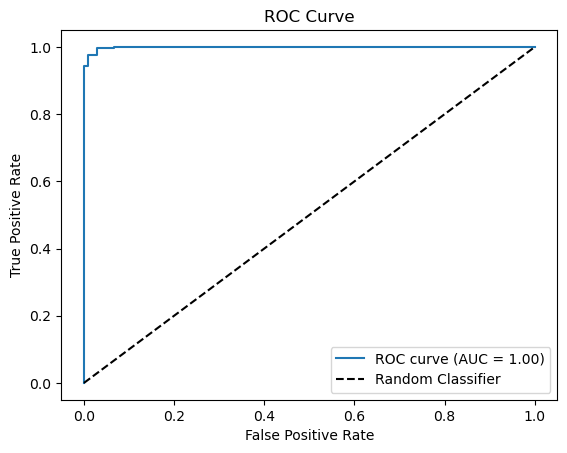

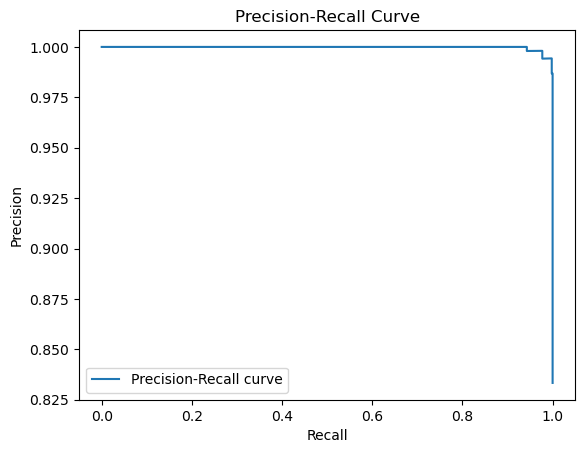

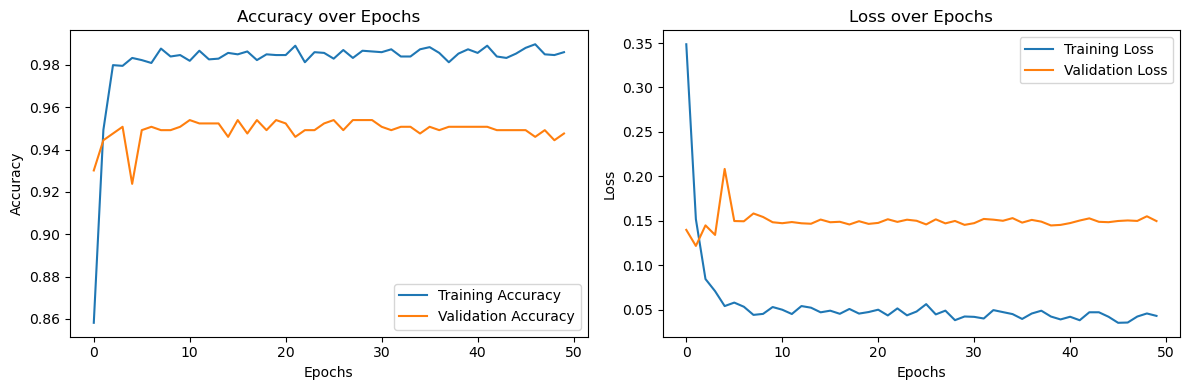

In [21]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Load images function
img_size = 224  # MobileNetV2 input size is (224, 224)
def load_images(base_path, img_size):
    data, labels = [], []
    categories = ['Tuberculosis', 'Normal']
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize

# Reshape for MobileNet input
data = np.stack((data,)*3, axis=-1)  # Convert grayscale to 3 channels (224,224,3)
print("Data shape:", data.shape)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

# Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30, zoom_range=0.2,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, fill_mode='nearest'
)
data_generator.fit(X_train)

# Step 4: Load Pretrained MobileNetV2 Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Step 5: Build the Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=1e-5)

# Train model
history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report & Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Data shape: (4200, 224, 224, 3)
Train shape: (2940, 224, 224, 3), Val shape: (630, 224, 224, 3), Test shape: (630, 224, 224, 3)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7633 - loss: 0.5258 - val_accuracy: 0.9254 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9455 - loss: 0.1712 - val_accuracy: 0.9397 - val_loss: 0.1328 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9634 - loss: 0.1086 - val_accuracy: 0.9476 - val_loss: 0.1478 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9846 - loss: 0.0556 - val_accuracy: 0.9492 - val_loss: 0.1282 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9761 - loss: 0.0700 - val_accuracy: 0.9048 - val_loss: 0.2636 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9792 - loss: 0.0612 - val_accuracy: 0.9032 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.9786 - loss: 0.0534
Epoch 7: ReduceLROn

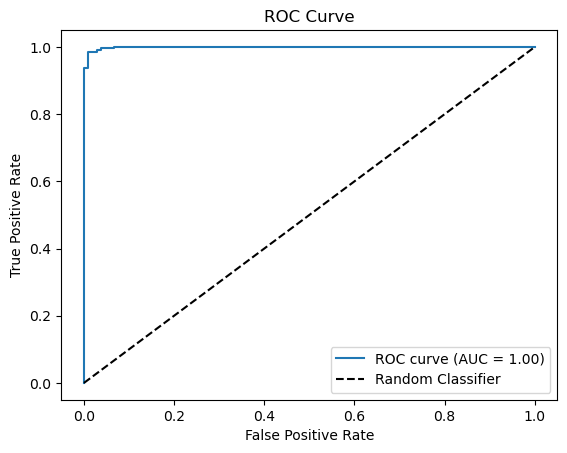

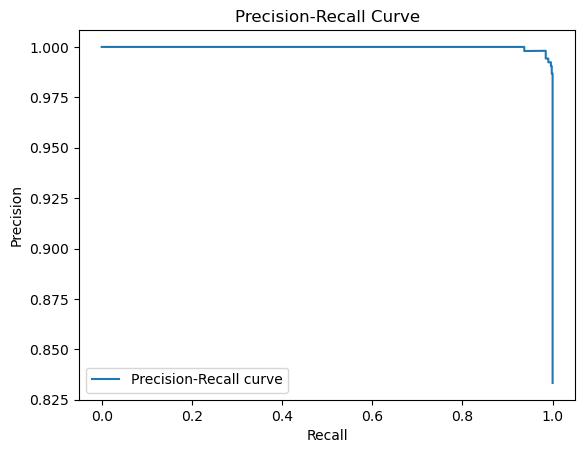

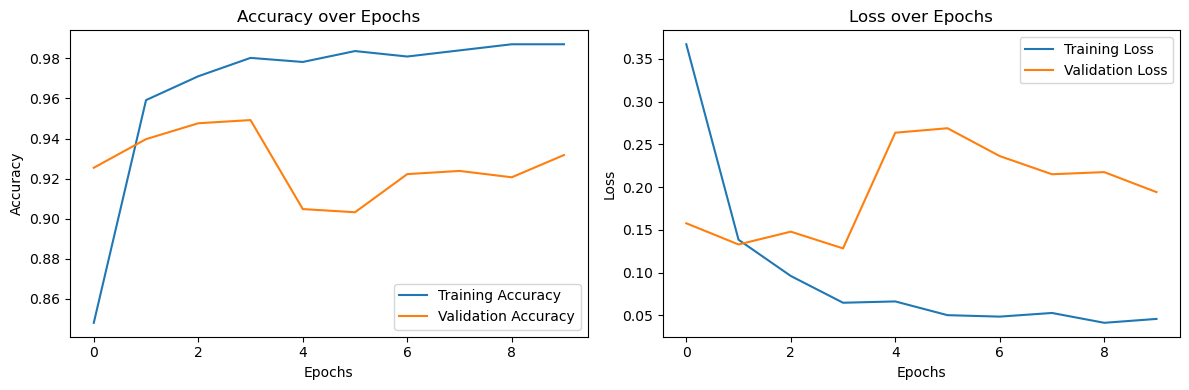

In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Load images function
img_size = 224  # MobileNetV2 input size is (224, 224)
def load_images(base_path, img_size):
    data, labels = [], []
    categories = ['Tuberculosis', 'Normal']
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize

# Reshape for MobileNet input
data = np.stack((data,)*3, axis=-1)  # Convert grayscale to 3 channels (224,224,3)
print("Data shape:", data.shape)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

# Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30, zoom_range=0.2,
    width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, fill_mode='nearest'
)
data_generator.fit(X_train)

# Step 4: Load Pretrained MobileNetV2 Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Step 5: Build the Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=1e-5)

# Train model
history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report & Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Found 3360 images belonging to 1 classes.
Found 840 images belonging to 1 classes.
Class Weights: {0: 1.0}
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 433s 4s/step - accuracy: 0.9656 - loss: 0.0720 - val_accuracy: 1.0000 - val_loss: 4.7629e-05 - learning_rate: 1.0000e-04
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 1.0000 - loss: 8.7273e-05 - val_accuracy: 1.0000 - val_loss: 1.5305e-05 - learning_rate: 1.0000e-04
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 1.0000 - loss: 3.7953e-05 - val_accuracy: 1.0000 - val_loss: 1.0326e-05 - learning_rate: 1.0000e-04
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 1.0000 - loss: 2.4132e-05
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
105/105 ━━━━━━━━━━━━━━━━━━━━ 385s 4s/step - accuracy: 1.0000 - loss: 2.4115e-05 - val_accuracy: 1.0000 - val_loss: 5.3737e-06 - learning_rate: 1.0000e-04
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 1.0000 - loss: 1.8577e-05 - val_accuracy: 1.0000 - val_loss: 4.4521e-06 - learning_rate: 2.0000e-05
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━

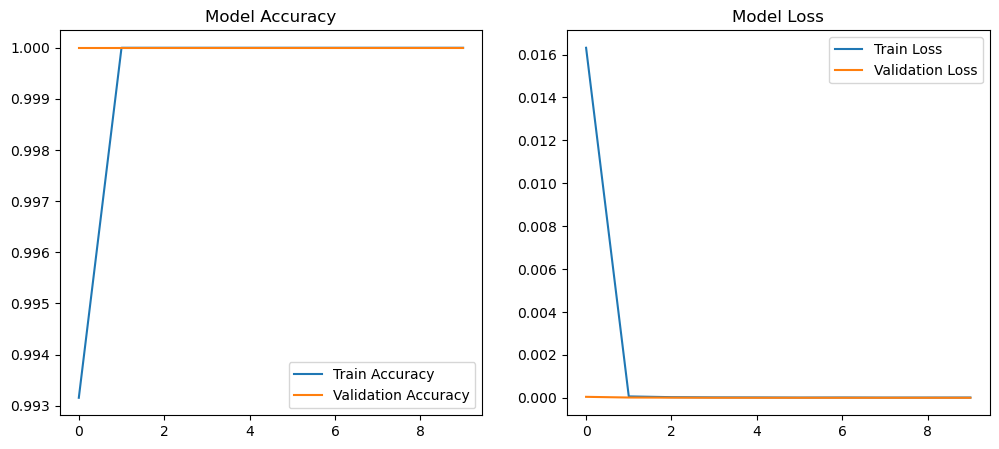

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:/Users/usER/Downloads/tb_xray_data/Test_Set/'

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load training and validation sets
train_generator = train_datagen.flow_from_directory(
    'C:/Users/usER/Downloads/tb_xray_data/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'C:/Users/usER/Downloads/tb_xray_data/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", class_weight_dict)

# Load pretrained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Define final model
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[lr_reducer, early_stopping]
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Load test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'C:/Users/usER/Downloads/tb_xray_data/Test_Set/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predictions on test data
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.8681 - loss: 0.3118 - val_accuracy: 0.8821 - val_loss: 0.3703
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.9587 - loss: 0.1152 - val_accuracy: 0.9274 - val_loss: 0.2084
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.9625 - loss: 0.1010 - val_accuracy: 0.9464 - val_loss: 0.1338
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - accuracy: 0.9719 - loss: 0.0794 - val_accuracy: 0.9476 - val_loss: 0.1435
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.9679 - loss: 0.0759 - val_accuracy: 0.9738 - val_loss: 0.0763
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.9784 - loss: 0.0644 - val_accuracy: 0.9536 - val_loss: 0.1149
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.9781 - loss: 0.0604 - val_accuracy: 0.9762 - val_loss: 0.0611
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.9783 - loss: 0.0671 - val_accuracy: 0.972

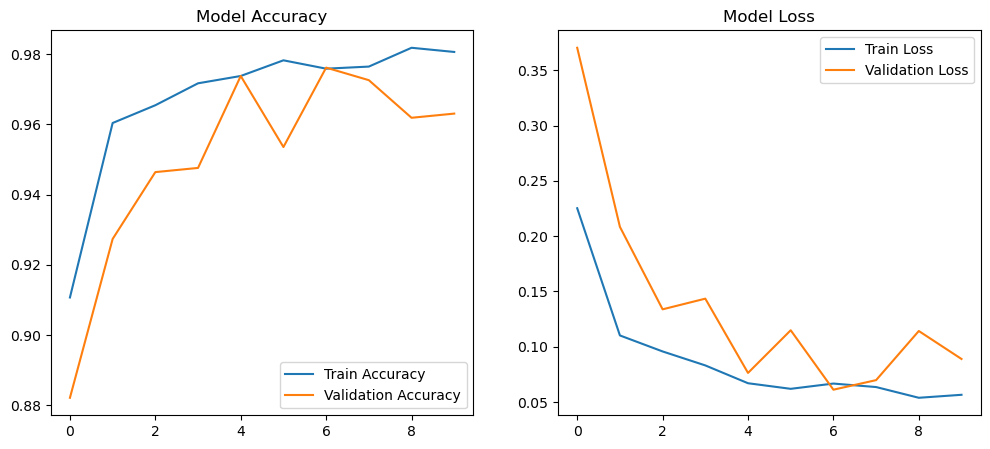

Found 4200 images belonging to 2 classes.
132/132 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9962 - loss: 0.0114

Test Accuracy: 0.9764
Test Loss: 0.0639
27/27 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step


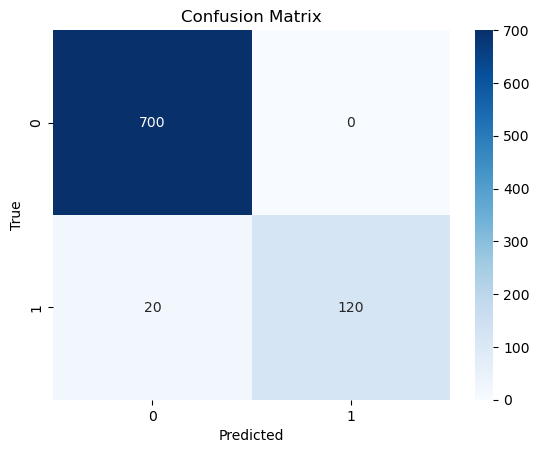


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.99       700
          TB       1.00      0.86      0.92       140

    accuracy                           0.98       840
   macro avg       0.99      0.93      0.95       840
weighted avg       0.98      0.98      0.98       840



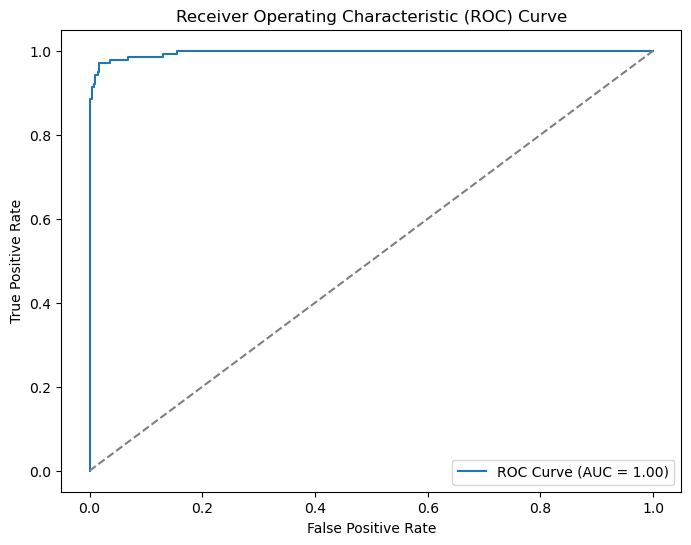

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last few layers of InceptionV3
for layer in base_model.layers[:-20]:  
    layer.trainable = False

# Build the model using InceptionV3 as the base
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Evaluate test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Evaluate model on validation data
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.8043 - loss: 0.4437 - val_accuracy: 0.8940 - val_loss: 0.2206
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.9468 - loss: 0.1447 - val_accuracy: 0.9238 - val_loss: 0.1729
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9615 - loss: 0.1078 - val_accuracy: 0.9667 - val_loss: 0.0922
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.9660 - loss: 0.0951 - val_accuracy: 0.9714 - val_loss: 0.0900
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9713 - loss: 0.0712 - val_accuracy: 0.9607 - val_loss: 0.0981
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9774 - loss: 0.0669 - val_accuracy: 0.9726 - val_loss: 0.0849
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9756 - loss: 0.0682 - val_accuracy: 0.9869 - val_loss: 0.0478
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9799 - loss: 0.0593 - val_accuracy: 0.976

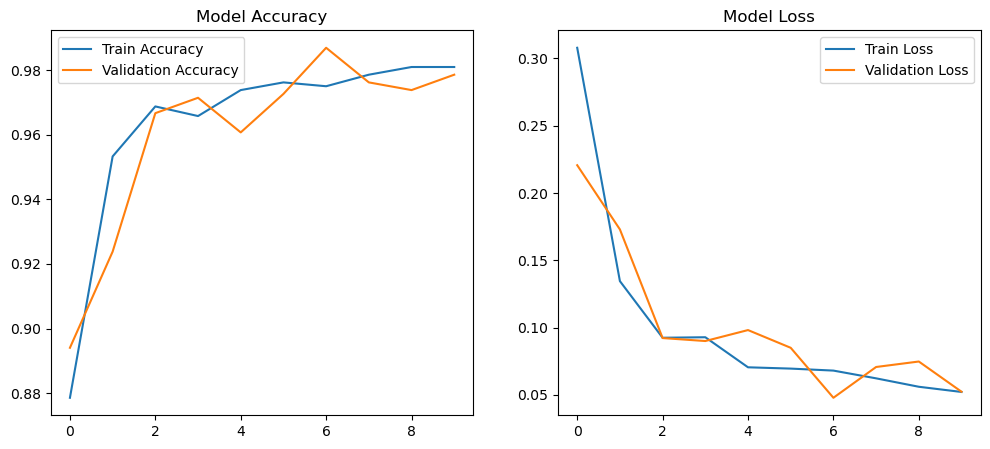

Found 4200 images belonging to 2 classes.
132/132 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9965 - loss: 0.0095

Test Accuracy: 0.9700
Test Loss: 0.0789
27/27 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step


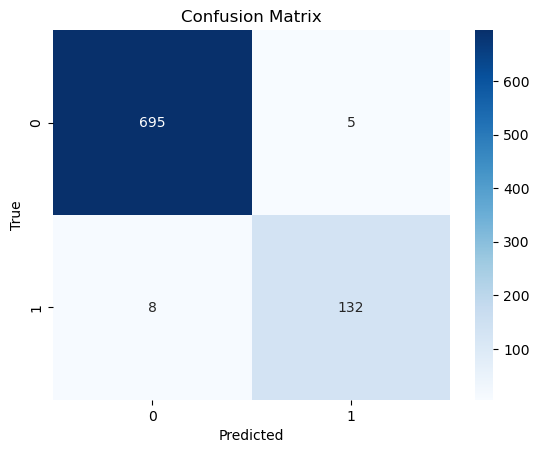


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       700
          TB       0.96      0.94      0.95       140

    accuracy                           0.98       840
   macro avg       0.98      0.97      0.97       840
weighted avg       0.98      0.98      0.98       840



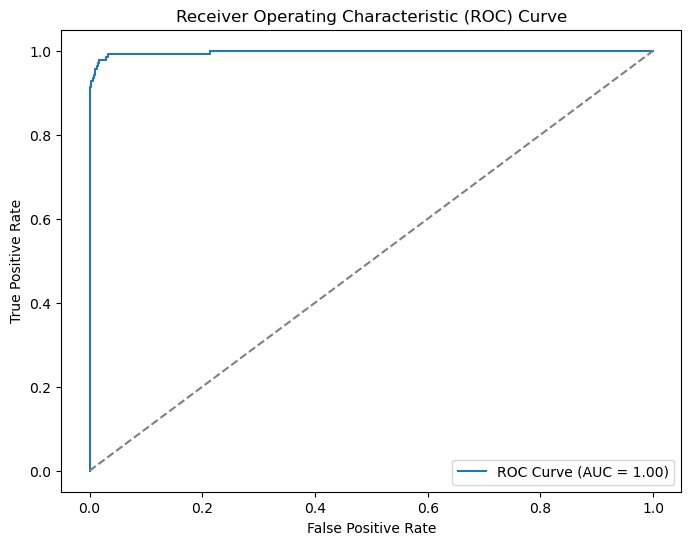

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained MobileNet model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
base_model.trainable = False

# Build the model using MobileNet as the base
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Evaluate test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Evaluate model on validation data
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 1602s 15s/step - accuracy: 0.8922 - loss: 0.2578 - val_accuracy: 0.9607 - val_loss: 0.1001
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1711s 16s/step - accuracy: 0.9873 - loss: 0.0504 - val_accuracy: 0.9869 - val_loss: 0.0529
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1467s 14s/step - accuracy: 0.9945 - loss: 0.0282 - val_accuracy: 0.9869 - val_loss: 0.0536
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1308s 12s/step - accuracy: 0.9978 - loss: 0.0164 - val_accuracy: 0.9893 - val_loss: 0.0390
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1533s 15s/step - accuracy: 0.9967 - loss: 0.0136 - val_accuracy: 0.9893 - val_loss: 0.0360
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1527s 15s/step - accuracy: 0.9989 - loss: 0.0096 - val_accuracy: 0.9893 - val_loss: 0.0396
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1306s 12s/step - accuracy: 0.9978 - loss: 0.0091 - val_accuracy: 0.9869 - val_loss: 0.0453
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1612s 15s/step - accuracy: 0.9981 - loss: 0.0070 - val

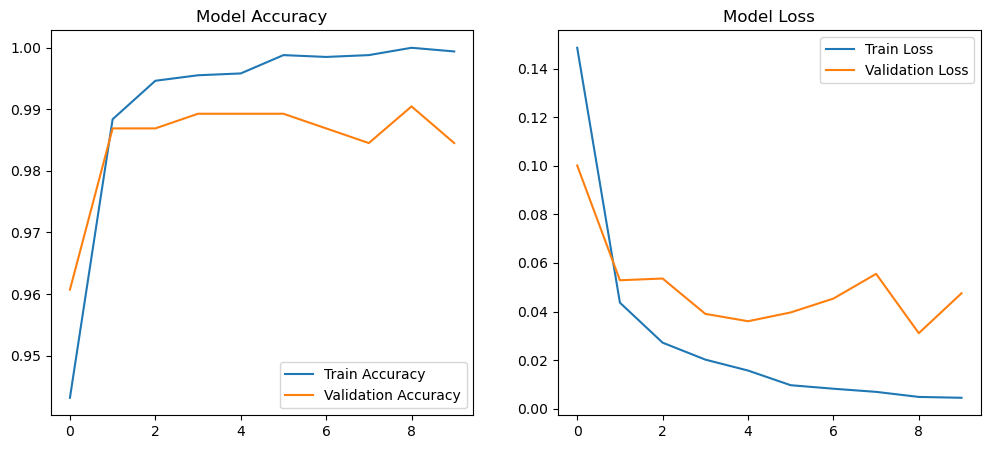

27/27 ━━━━━━━━━━━━━━━━━━━━ 319s 12s/step


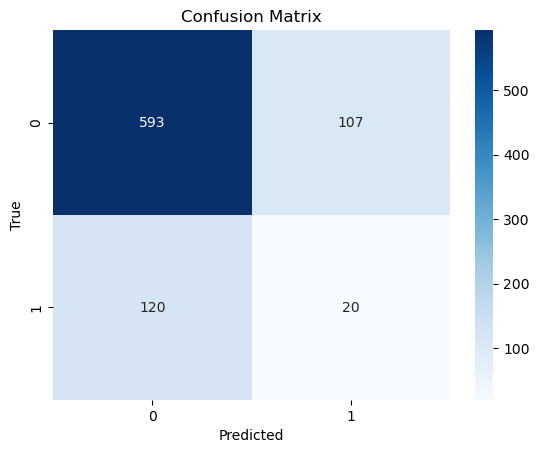


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       700
           1       0.16      0.14      0.15       140

    accuracy                           0.73       840
   macro avg       0.49      0.49      0.49       840
weighted avg       0.72      0.73      0.72       840

27/27 ━━━━━━━━━━━━━━━━━━━━ 317s 12s/step


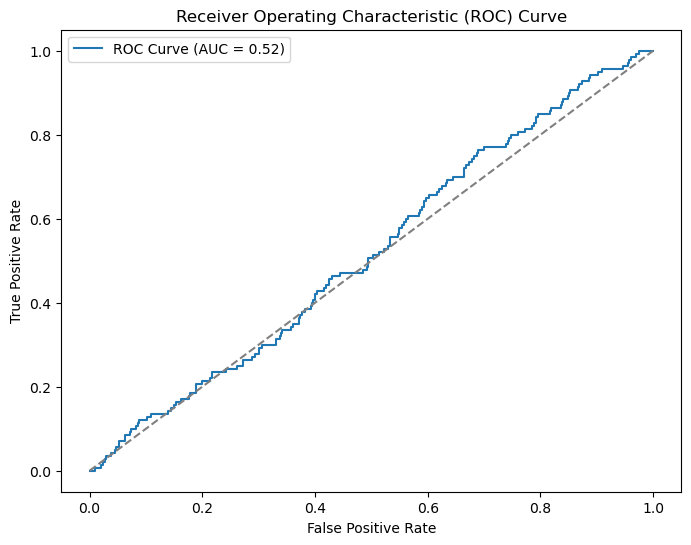

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training')
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation')

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers

# Build model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred))

# ROC Curve
y_pred_probs = model.predict(val_generator).ravel()
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Train size: 2940, Validation size: 630, Test size: 630
Found 2940 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.
Found 630 validated image filenames belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 1645s 18s/step - accuracy: 0.8400 - loss: 0.3685 - val_accuracy: 0.9746 - val_loss: 0.0865
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1570s 17s/step - accuracy: 0.9676 - loss: 0.0955 - val_accuracy: 0.9778 - val_loss: 0.0608
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1432s 16s/step - accuracy: 0.9706 - loss: 0.0869 - val_accuracy: 0.9857 - val_loss: 0.0426
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1530s 17s/step - accuracy: 0.9853 - loss: 0.0443 - val_accuracy: 0.9746 - val_loss: 0.0557
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1517s 16s/step - accuracy: 0.9831 - loss: 0.0488 - val_accuracy: 0.9762 - val_loss: 0.0509
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1298s 14s/step - accuracy: 0.9837 - loss: 0.0487 - val_accuracy: 0.9873 - val_loss: 0.0400
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1319s 14s/step - accuracy: 0.9820 - loss: 0.0486 - val_accuracy: 0.9810 - val_loss: 0.0363
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1607s 17s/step - accuracy: 0.9891 - loss: 0.0442 - val_accuracy: 0.992

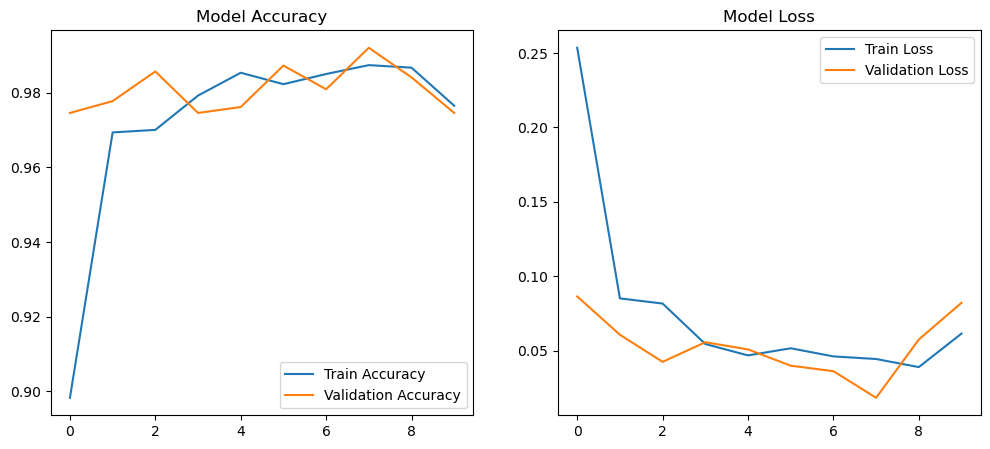

20/20 ━━━━━━━━━━━━━━━━━━━━ 186s 9s/step - accuracy: 0.9713 - loss: 0.0955
Test Accuracy: 96.83%
20/20 ━━━━━━━━━━━━━━━━━━━━ 184s 9s/step


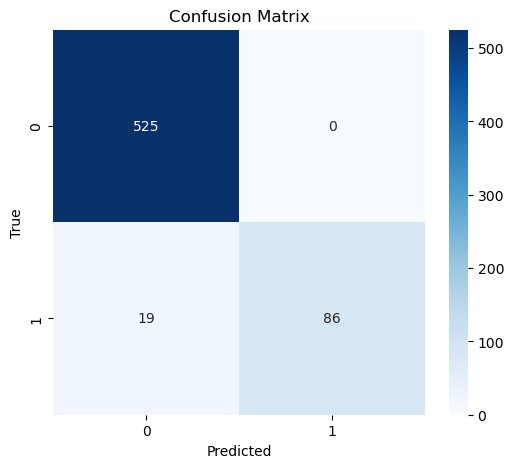


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       525
          TB       1.00      0.82      0.90       105

    accuracy                           0.97       630
   macro avg       0.98      0.91      0.94       630
weighted avg       0.97      0.97      0.97       630



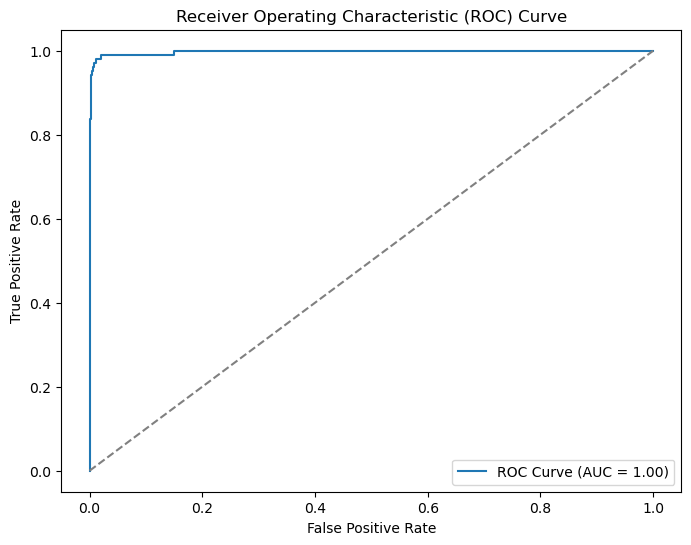

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths = []
labels = []

# Define categories
categories = ['Normal', 'Tuberculosis']

# Loop through directories and collect image paths and labels
for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)  # Using string labels directly

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})

# **Step 4: Split dataset (Train 70%, Validation 15%, Test 15%)**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

# **Step 5: Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='binary', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='binary', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='binary', shuffle=False
)

# **Step 7: Load VGG16 (Pretrained)**
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune: Unfreeze last 4 layers
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# **Step 8: Build the Model**
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# **Step 9: Compile Model**
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# **Step 10: Train Model**
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# **Step 11: Plot Training History**
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# **Step 12: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# **Step 13: Confusion Matrix & Classification Report**
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 14: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Train size: 2940, Validation size: 630, Test size: 630
Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 1219s 13s/step - accuracy: 0.8710 - loss: 0.3370 - val_accuracy: 0.9778 - val_loss: 0.0731
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1244s 13s/step - accuracy: 0.9708 - loss: 0.0897 - val_accuracy: 0.9778 - val_loss: 0.0561
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1428s 16s/step - accuracy: 0.9721 - loss: 0.0727 - val_accuracy: 0.9730 - val_loss: 0.0539
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1593s 17s/step - accuracy: 0.9777 - loss: 0.0573 - val_accuracy: 0.9968 - val_loss: 0.0117
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1452s 16s/step - accuracy: 0.9822 - loss: 0.0545 - val_accuracy: 0.9667 - val_loss: 0.1099
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1143s 12s/step - accuracy: 0.9814 - loss: 0.0500 - val_accuracy: 0.9921 - val_loss: 0.0285
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1212s 13s/step - accuracy: 0.9895 - loss: 0.0345 - val_accuracy: 0.9873 - val_loss: 0.0396
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1130s 12s/step - accuracy: 0.9829 - loss: 0.0556 - val_accuracy: 0.993

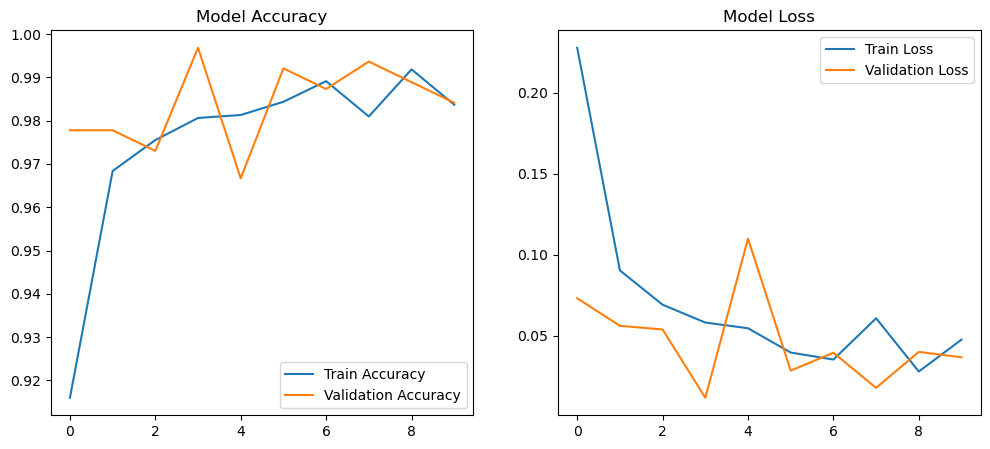

20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 8s/step - accuracy: 0.9938 - loss: 0.0337
Test Accuracy: 99.21%


AttributeError: 'DataFrameIterator' object has no attribute 'classes'

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths = []
labels = []

# Define categories
categories = ['Normal', 'Tuberculosis']

# Loop through directories and collect image paths and labels
for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})  # Convert labels to binary (0,1)

# **Step 4: Split dataset (Train 70%, Validation 15%, Test 15%)**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

# **Step 5: Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 7: Load VGG16 (Pretrained)**
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune: Unfreeze last 4 layers
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# **Step 8: Build the Model**
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# **Step 9: Compile Model**
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# **Step 10: Train Model**
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# **Step 11: Plot Training History**
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# **Step 12: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# **Step 13: Confusion Matrix & Classification Report**
y_true = test_df['label'].values
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 14: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [28]:
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Generate classification report & confusion matrix
print("Classification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


20/20 ━━━━━━━━━━━━━━━━━━━━ 243s 12s/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       525
           1       0.98      0.98      0.98       105

    accuracy                           0.99       630
   macro avg       0.99      0.99      0.99       630
weighted avg       0.99      0.99      0.99       630

Confusion Matrix:
 [[523   2]
 [  2 103]]


In [29]:
# Step 12: Evaluate on Test Set (Without Retraining)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 254s 13s/step - accuracy: 0.9843 - loss: 0.0449
Test Accuracy: 98.10%
Test Loss: 0.0640


Train size: 2940, Validation size: 630, Test size: 630
Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 1100s 12s/step - accuracy: 0.8815 - loss: 0.2958 - val_accuracy: 0.9746 - val_loss: 0.0800
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1063s 12s/step - accuracy: 0.9662 - loss: 0.0959 - val_accuracy: 0.9825 - val_loss: 0.0487
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1069s 12s/step - accuracy: 0.9781 - loss: 0.0688 - val_accuracy: 0.9841 - val_loss: 0.0441
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1059s 11s/step - accuracy: 0.9741 - loss: 0.0676 - val_accuracy: 0.9746 - val_loss: 0.0689
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1590s 17s/step - accuracy: 0.9837 - loss: 0.0470 - val_accuracy: 0.9825 - val_loss: 0.0439
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1665s 18s/step - accuracy: 0.9825 - loss: 0.0502 - val_accuracy: 0.9889 - val_loss: 0.0374
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1465s 16s/step - accuracy: 0.9864 - loss: 0.0429 - val_accuracy: 0.9889 - val_loss: 0.0239
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 1311s 14s/step - accuracy: 0.9834 - loss: 0.0504 - val_accuracy: 0.984

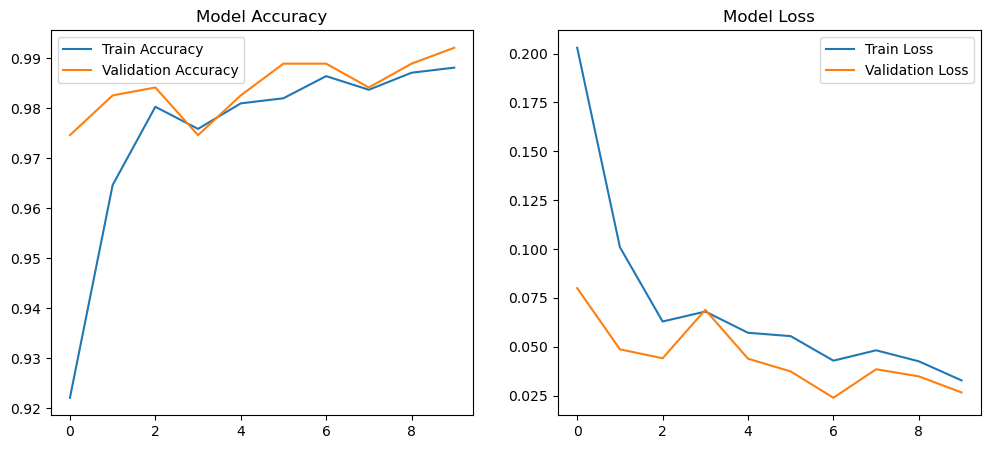

20/20 ━━━━━━━━━━━━━━━━━━━━ 178s 9s/step - accuracy: 0.9915 - loss: 0.0304
Test Accuracy: 98.73%
Test Loss: 0.0428
20/20 ━━━━━━━━━━━━━━━━━━━━ 192s 10s/step


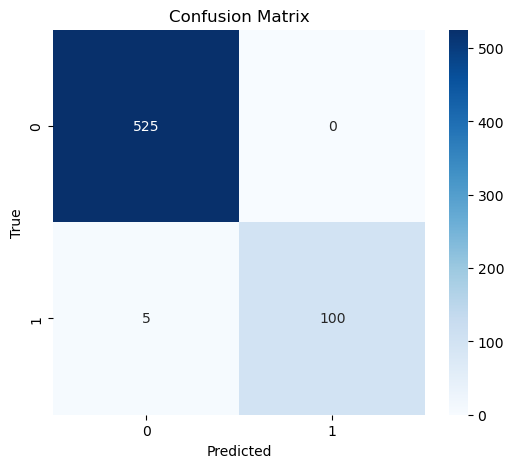


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       525
          TB       1.00      0.95      0.98       105

    accuracy                           0.99       630
   macro avg       1.00      0.98      0.99       630
weighted avg       0.99      0.99      0.99       630



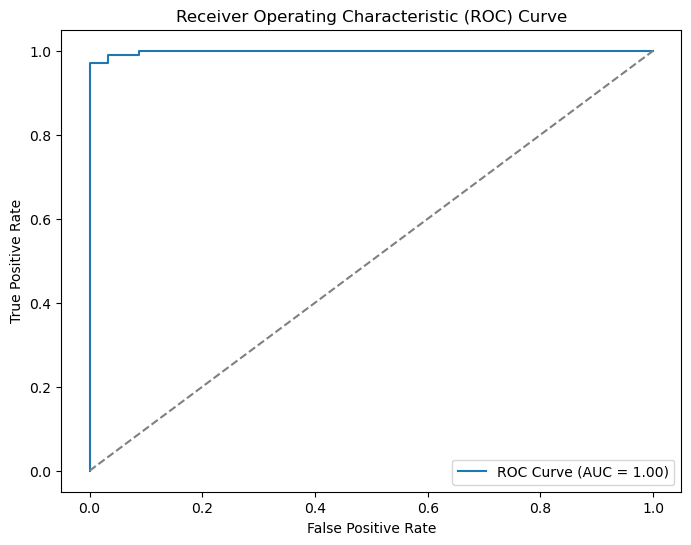

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths = []
labels = []

# Define categories
categories = ['Normal', 'Tuberculosis']

# Loop through directories and collect image paths and labels
for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})  # Convert labels to binary (0,1)

# **Step 4: Split dataset (Train 70%, Validation 15%, Test 15%)**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

# **Step 5: Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 7: Load VGG16 (Pretrained)**
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune: Unfreeze last 4 layers
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# **Step 8: Build the Model**
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# **Step 9: Compile Model**
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# **Step 10: Train Model**
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# **Step 11: Plot Training History**
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()
# **Step 12: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")  # Added test loss output

# **Step 13: Confusion Matrix & Classification Report**
y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 14: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 525s 5s/step - accuracy: 0.4381 - loss: 0.9402 - val_accuracy: 0.8397 - val_loss: 0.3780 - learning_rate: 1.0000e-05
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 466s 5s/step - accuracy: 0.8446 - loss: 0.3960 - val_accuracy: 0.8587 - val_loss: 0.2962 - learning_rate: 1.0000e-05
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 449s 5s/step - accuracy: 0.8610 - loss: 0.3456 - val_accuracy: 0.8952 - val_loss: 0.2360 - learning_rate: 1.0000e-05
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 450s 5s/step - accuracy: 0.8970 - loss: 0.2716 - val_accuracy: 0.9159 - val_loss: 0.1918 - learning_rate: 1.0000e-05
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 446s 5s/step - accuracy: 0.9096 - loss: 0.2284 - val_accuracy: 0.9286 - val_loss: 0.1572 - learning_rate: 1.0000e-05
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 451s 5s/step - accuracy: 0.9322 - loss: 0.1979 - val_accuracy: 0.9397 - val_loss: 0.1357 - learning_rate: 1.0000e-05
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 511s 5s/step - accuracy: 0.9275 - loss: 0.1

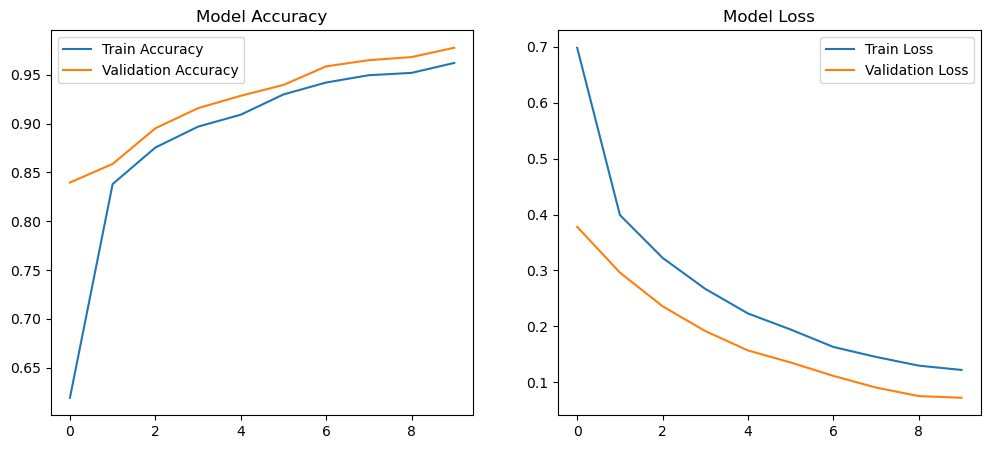

20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.9817 - loss: 0.0657
Test Accuracy: 97.94%
Test Loss: 0.0712
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step


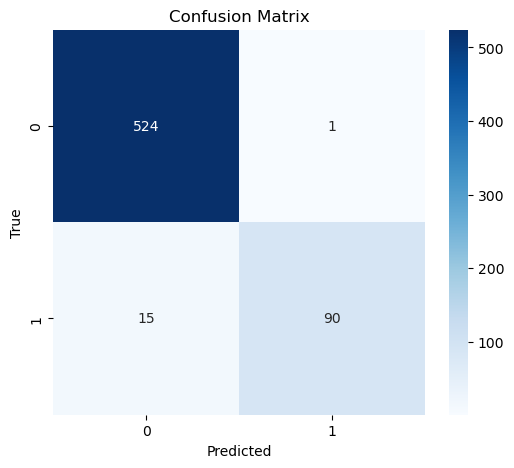


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       525
          TB       0.99      0.86      0.92       105

    accuracy                           0.97       630
   macro avg       0.98      0.93      0.95       630
weighted avg       0.97      0.97      0.97       630



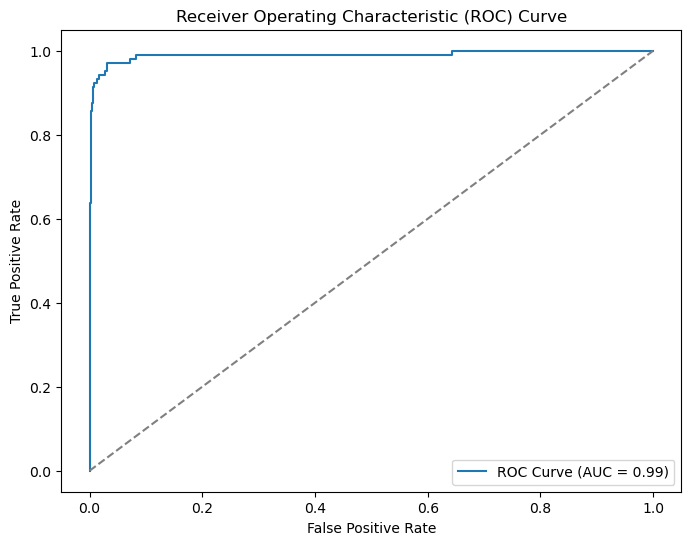

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths, labels = [], []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Step 4: Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# **Step 5: Adjusted Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)
val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)
test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 7: Load DenseNet121 (Pretrained)**
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# **Step 8: Fine-Tune the Last 50 Layers**
base_model.trainable = True
for layer in base_model.layers[:-50]:  # Freeze first 50 layers, train the rest
    layer.trainable = False

# **Step 9: Build the Model**
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# **Step 10: Compile Model with Lower Learning Rate**
model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy'])

# **Step 11: Train Model with Learning Rate Decay**
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
history = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=[lr_scheduler])

# **Step 12: Plot Training History**
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# **Step 13: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# **Step 14: Confusion Matrix & Classification Report**
y_true = test_df['label'].values
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 15: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.6768 - loss: 0.6662 - val_accuracy: 0.9667 - val_loss: 0.1105
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9781 - loss: 0.0665 - val_accuracy: 0.9556 - val_loss: 0.0843
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9930 - loss: 0.0246 - val_accuracy: 0.8968 - val_loss: 0.2897
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9920 - loss: 0.0231 - val_accuracy: 0.9698 - val_loss: 0.0770
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.9967 - loss: 0.0118 - val_accuracy: 0.9397 - val_loss: 0.1855
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.9957 - loss: 0.0120 - val_accuracy: 0.9873 - val_loss: 0.0327
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9976 - loss: 0.0082 - val_accuracy: 0.9730 - val_loss: 0.1044
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9778 - val_loss: 0.

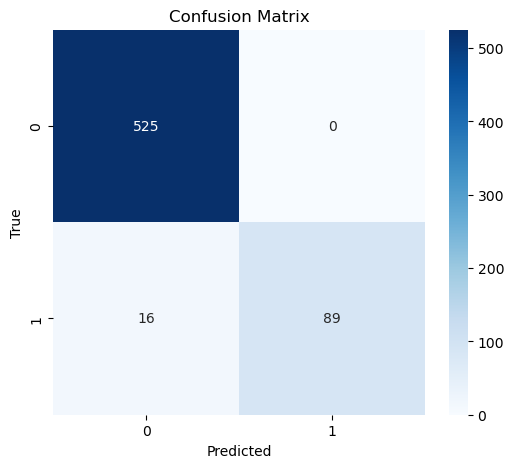


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.98       525
          TB       1.00      0.85      0.92       105

    accuracy                           0.97       630
   macro avg       0.99      0.92      0.95       630
weighted avg       0.98      0.97      0.97       630



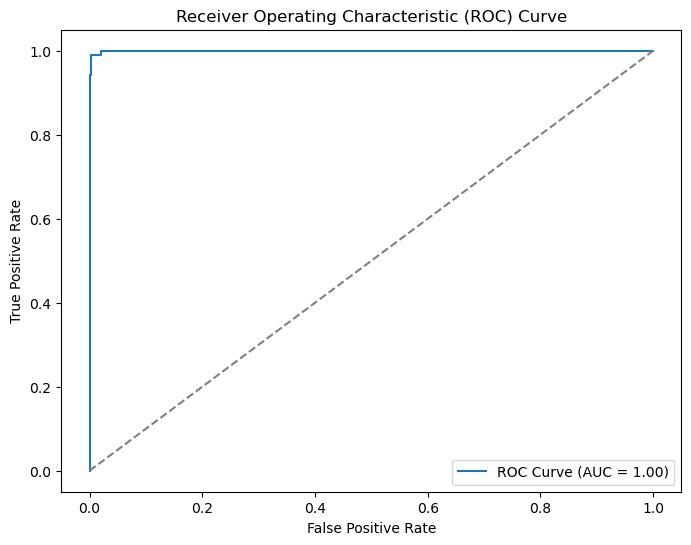

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths, labels = [], []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Step 4: Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# **Step 5: Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)
val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)
test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 7: Load MobileNetV2 (Pretrained)**
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Fine-tune the last 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# **Step 8: Build the Model**
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# **Step 9: Compile Model**
initial_learning_rate = 1e-4
decay_rate = initial_learning_rate / 30
model.compile(optimizer=Adam(learning_rate=initial_learning_rate, decay=decay_rate), 
              loss='binary_crossentropy', metrics=['accuracy'])

# **Step 10: Train Model**
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# **Step 11: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# **Step 12: Confusion Matrix & Classification Report**
y_true = test_df['label'].values
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 13: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.7892 - loss: 0.4418 - val_accuracy: 0.3937 - val_loss: 1.2442 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.9760 - loss: 0.0689 - val_accuracy: 0.3286 - val_loss: 2.2779 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.9877 - loss: 0.0388 - val_accuracy: 0.6460 - val_loss: 0.9462 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.9925 - loss: 0.0229 - val_accuracy: 0.5286 - val_loss: 1.3832 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9837 - loss: 0.0366
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
92/92 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9837 - loss: 0.0365 - val_accuracy: 0.4937 - val_loss: 1.9334 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.9866 - loss: 0.0273 - v

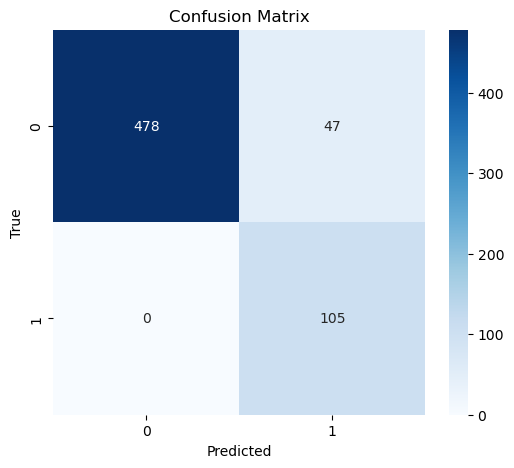


Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.91      0.95       525
          TB       0.69      1.00      0.82       105

    accuracy                           0.93       630
   macro avg       0.85      0.96      0.89       630
weighted avg       0.95      0.93      0.93       630



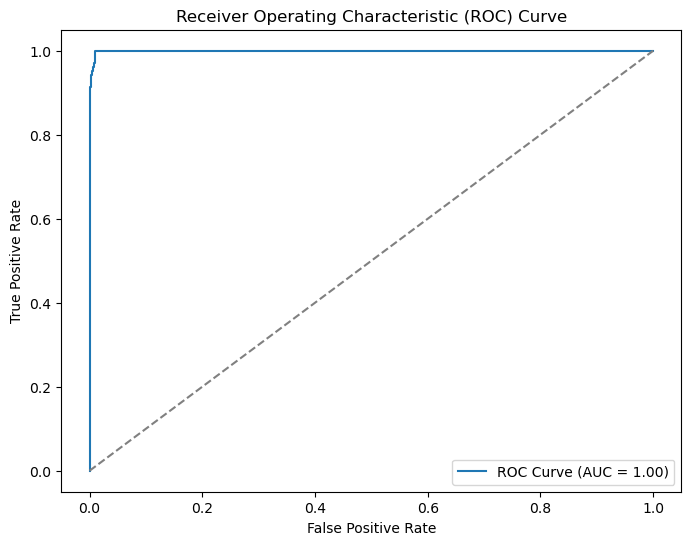

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Dataset Path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Load and preprocess data**
image_paths, labels = [], []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# **Compute Class Weights**
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

# **Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)
val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)
test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Load MobileNetV2 (Pretrained)**
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# **Unfreeze last 100 layers for fine-tuning**
for layer in base_model.layers[:-100]:
    layer.trainable = False

# **Build Model**
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# **Compile Model**
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# **Learning Rate Scheduler**
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# **Train Model with Class Weights**
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler]
)

# **Evaluate Model**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# **Confusion Matrix & Classification Report**
y_true = test_df['label'].values
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 2940 validated image filenames.
Found 630 validated image filenames.
Found 630 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8279 - loss: 1.4654 - val_accuracy: 0.9540 - val_loss: 1.1269 - learning_rate: 1.0000e-04
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9374 - loss: 1.1406 - val_accuracy: 0.9635 - val_loss: 1.0349 - learning_rate: 1.0000e-04
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9497 - loss: 1.0422 - val_accuracy: 0.9667 - val_loss: 0.9520 - learning_rate: 1.0000e-04
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9622 - loss: 0.9614 - val_accuracy: 0.9746 - val_loss: 0.8997 - learning_rate: 1.0000e-04
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9659 - loss: 0.8976 - val_accuracy: 0.9746 - val_loss: 0.8438 - learning_rate: 1.0000e-04
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9672 - loss: 0.8566 - val_accuracy: 0.9794 - val_loss: 0.7952 - learning_rate: 1.0000e-04
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9654 - loss: 0.8

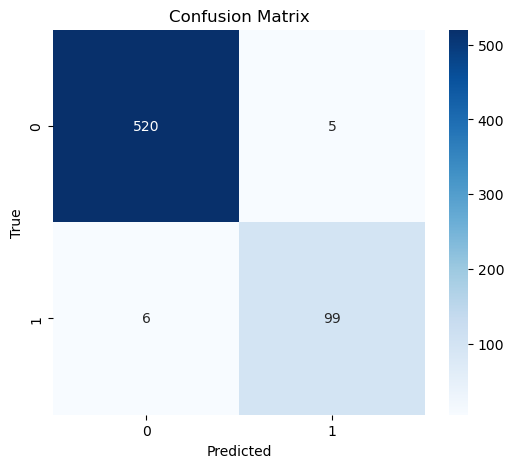


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       525
          TB       0.95      0.94      0.95       105

    accuracy                           0.98       630
   macro avg       0.97      0.97      0.97       630
weighted avg       0.98      0.98      0.98       630



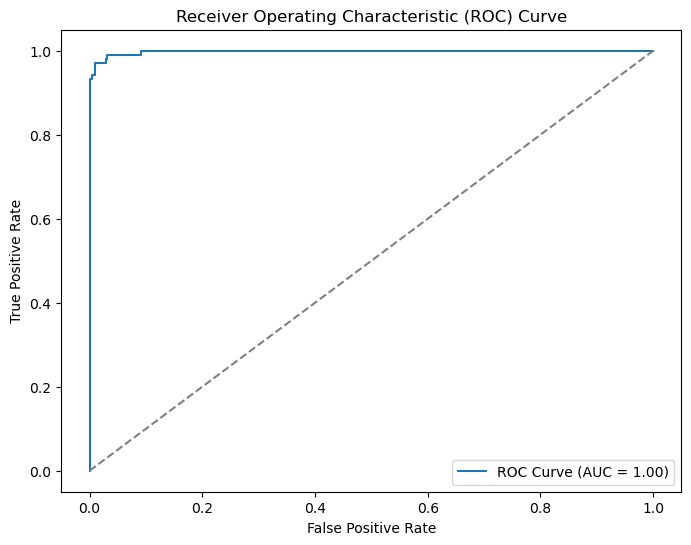

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Step 1: Define dataset path**
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths, labels = [], []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Step 4: Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# **Step 5: Enhanced Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],  # New: Adjust brightness
    horizontal_flip=True,
    fill_mode='nearest'
)

# **Step 6: Create Image Generators**
train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=True
)
val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)
test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(224, 224), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 7: Load MobileNetV2 (Pretrained)**
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers initially

# **Step 8: Build the Model with Regularization**
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# **Step 9: Compile Model**
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# **Step 10: Define Callbacks**
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# **Step 11: Train Model (Initial Phase)**
history = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=[lr_scheduler])

# **Step 12: Unfreeze the Last Few Layers & Fine-Tune**
base_model.trainable = True
for layer in base_model.layers[:-30]:  # Keep first layers frozen
    layer.trainable = False

# Compile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=5e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train for fine-tuning
history_fine = model.fit(train_generator, validation_data=val_generator, epochs=10, callbacks=[lr_scheduler])

# **Step 13: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# **Step 14: Confusion Matrix & Classification Report**
y_true = test_df['label'].values
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 15: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1295s 12s/step - accuracy: 0.8764 - loss: 0.2943 - val_accuracy: 0.9583 - val_loss: 0.0962
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1332s 13s/step - accuracy: 0.9699 - loss: 0.0791 - val_accuracy: 0.9619 - val_loss: 0.1192
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1477s 14s/step - accuracy: 0.9791 - loss: 0.0542 - val_accuracy: 0.9226 - val_loss: 0.2249
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1431s 14s/step - accuracy: 0.9791 - loss: 0.0550 - val_accuracy: 0.9619 - val_loss: 0.1463
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1412s 13s/step - accuracy: 0.9883 - loss: 0.0440 - val_accuracy: 0.9714 - val_loss: 0.0684
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1512s 14s/step - accuracy: 0.9808 - loss: 0.0461 - val_accuracy: 0.9798 - val_loss: 0.0767
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1432s 14s/step - accuracy: 0.9875 - loss: 0.0345 - val_accuracy: 0.9714 - val_loss: 0.0934


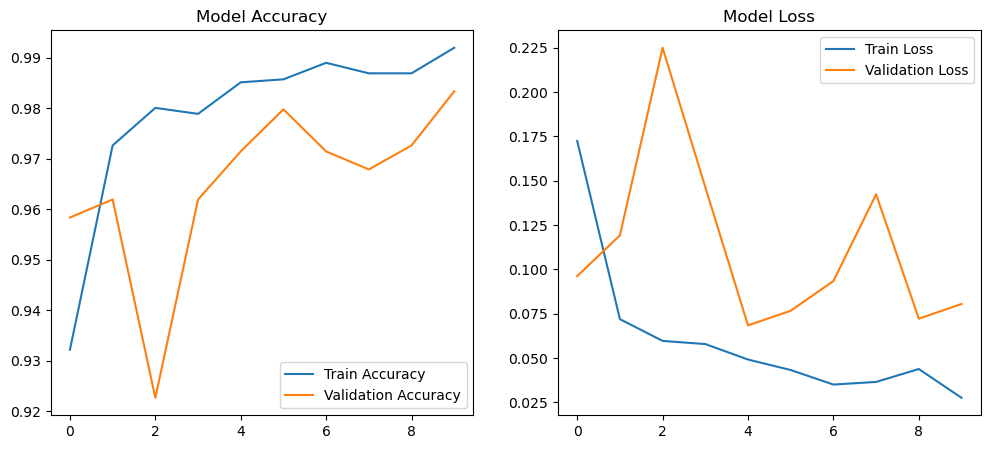

27/27 ━━━━━━━━━━━━━━━━━━━━ 251s 9s/step


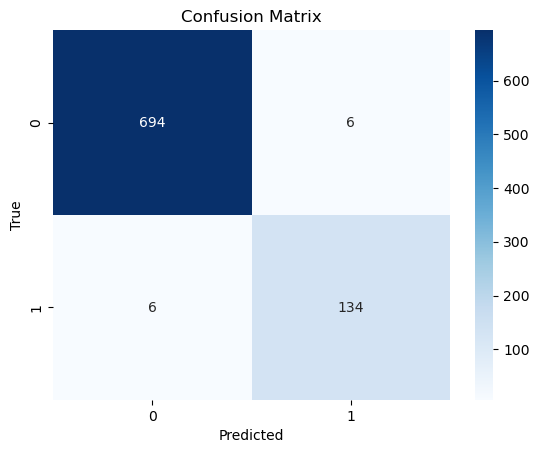


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       700
          TB       0.96      0.96      0.96       140

    accuracy                           0.99       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.99      0.99      0.99       840

F1-Score: 0.9571


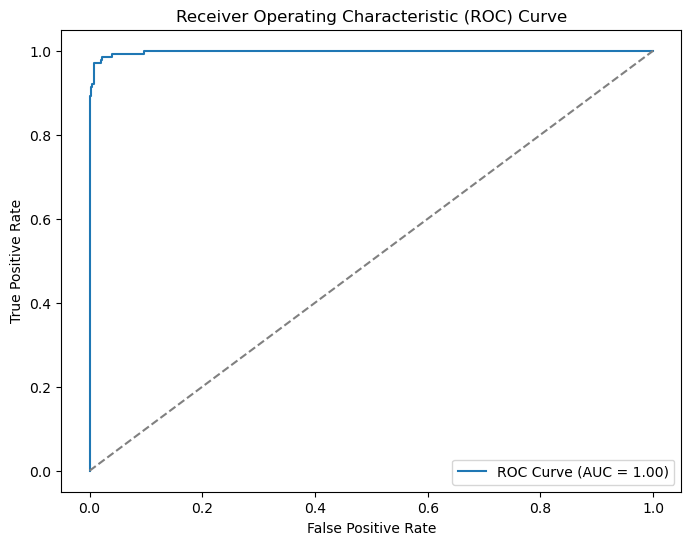

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last 4 layers of VGG16
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# Build the model using VGG16 as the base
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# Extract and display F1-score
f1_score = report['TB']['f1-score']
print(f"F1-Score: {f1_score:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


105/105 ━━━━━━━━━━━━━━━━━━━━ 1615s 15s/step - accuracy: 0.8685 - loss: 0.3481 - val_accuracy: 0.9560 - val_loss: 0.1137


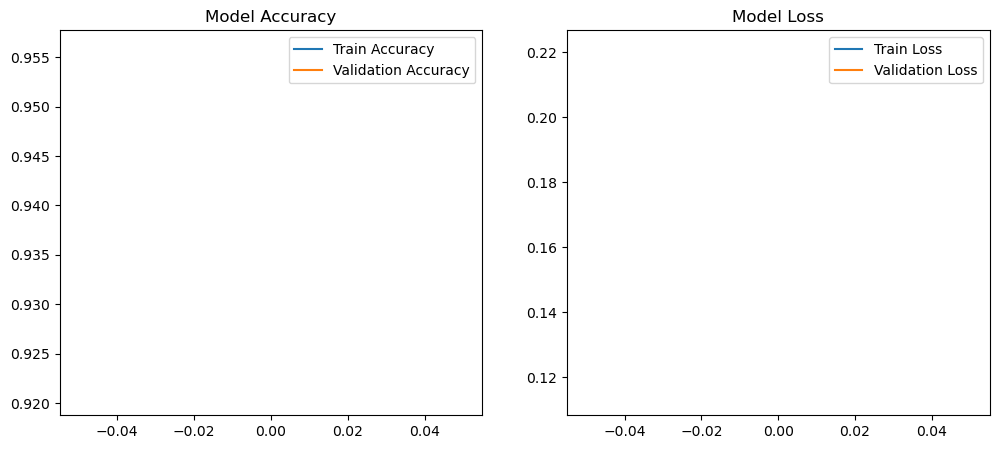

Found 4200 images belonging to 2 classes.
84/84 ━━━━━━━━━━━━━━━━━━━━ 1268s 15s/step - accuracy: 0.9968 - loss: 0.0110

Test Accuracy: 0.9795
Test Loss: 0.0505
27/27 ━━━━━━━━━━━━━━━━━━━━ 231s 9s/step


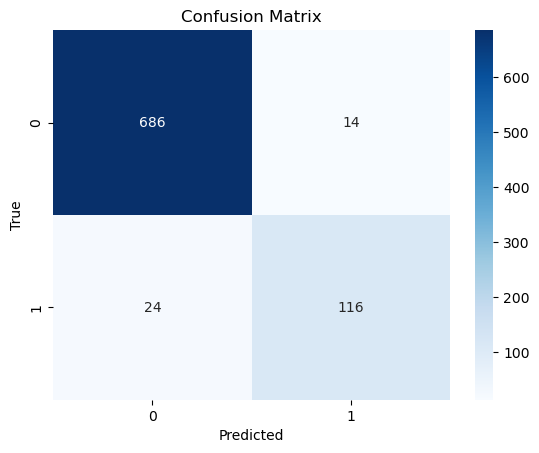


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      0.98      0.97       700
          TB       0.89      0.83      0.86       140

    accuracy                           0.95       840
   macro avg       0.93      0.90      0.92       840
weighted avg       0.95      0.95      0.95       840



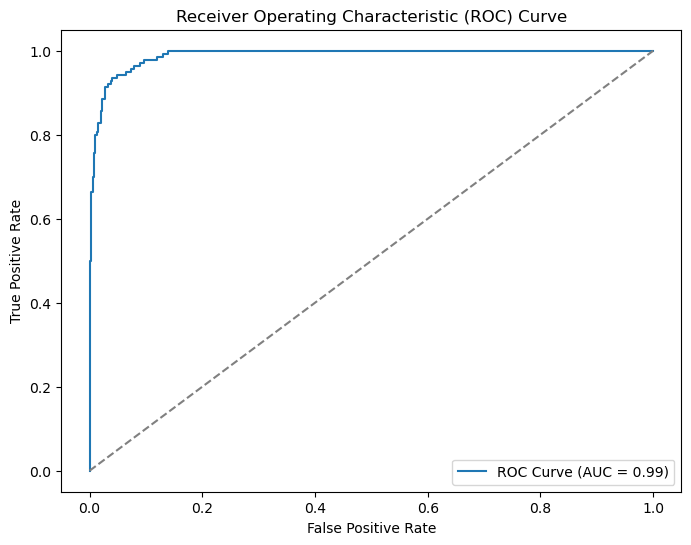

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last 4 layers of VGG16
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# Build the model using VGG16 as the base
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Evaluate test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Evaluate model on validation data
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 1660s 16s/step - accuracy: 0.8659 - loss: 0.3193 - val_accuracy: 0.9583 - val_loss: 0.1148
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1781s 17s/step - accuracy: 0.9720 - loss: 0.0804 - val_accuracy: 0.9440 - val_loss: 0.1340
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1947s 18s/step - accuracy: 0.9744 - loss: 0.0812 - val_accuracy: 0.9738 - val_loss: 0.0787
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1727s 16s/step - accuracy: 0.9842 - loss: 0.0494 - val_accuracy: 0.9738 - val_loss: 0.0703
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1519s 14s/step - accuracy: 0.9862 - loss: 0.0387 - val_accuracy: 0.9762 - val_loss: 0.0622
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1583s 15s/step - accuracy: 0.9865 - loss: 0.0472 - val_accuracy: 0.9726 - val_loss: 0.0755
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1377s 13s/step - accuracy: 0.9881 - loss: 0.0304 - val_accuracy: 0.9429 - val_loss: 0.1365
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1502s 14s/step - accuracy: 0.9884 - loss: 0.0465 - val

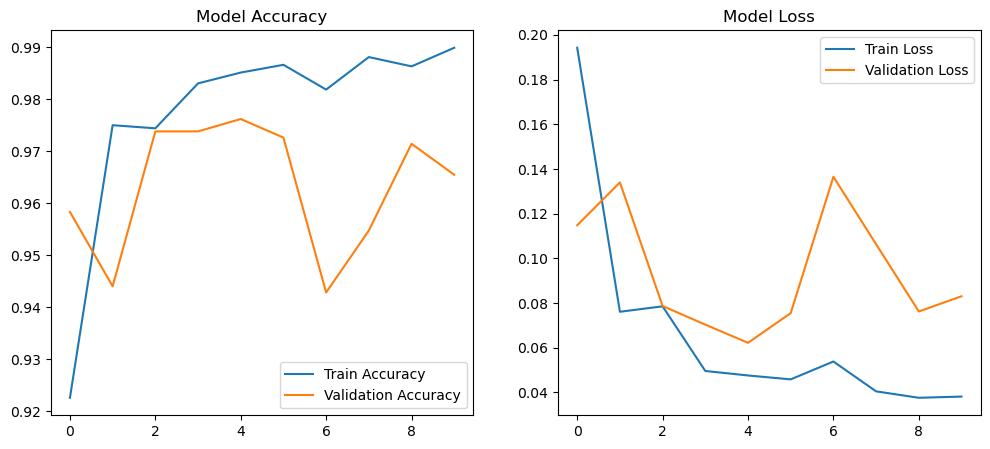

Found 4200 images belonging to 2 classes.
132/132 ━━━━━━━━━━━━━━━━━━━━ 1060s 8s/step - accuracy: 0.9989 - loss: 0.0027

Test Accuracy: 0.9969
Test Loss: 0.0102
27/27 ━━━━━━━━━━━━━━━━━━━━ 220s 8s/step


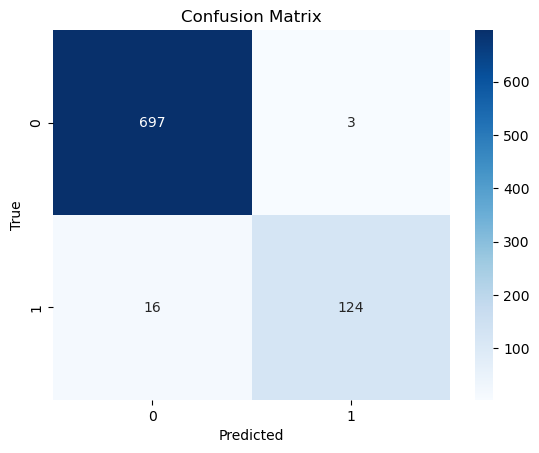


Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       700
          TB       0.98      0.89      0.93       140

    accuracy                           0.98       840
   macro avg       0.98      0.94      0.96       840
weighted avg       0.98      0.98      0.98       840



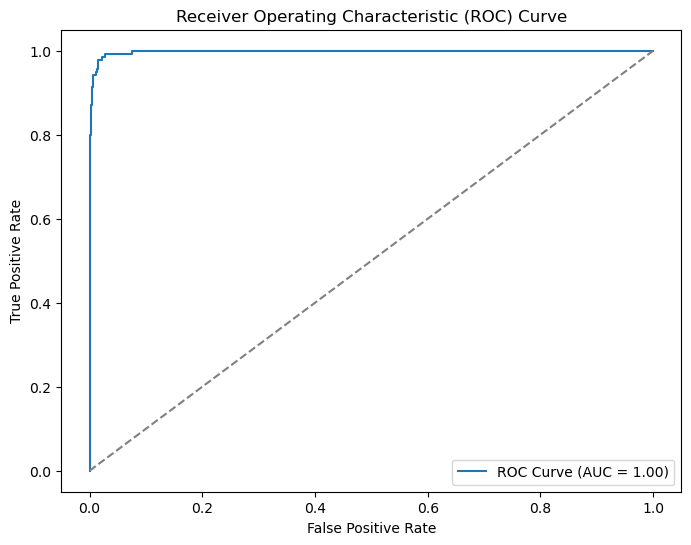

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last 4 layers of VGG16
for layer in base_model.layers[:-4]:  
    layer.trainable = False

# Build the model using VGG16 as the base
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Evaluate test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Evaluate model on validation data
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Updated Class Weights: {0: 0.6, 1: 3.0}
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 1564s 15s/step - accuracy: 0.7963 - loss: 0.7844 - val_accuracy: 0.9357 - val_loss: 0.4975
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1499s 14s/step - accuracy: 0.9540 - loss: 0.4449 - val_accuracy: 0.9560 - val_loss: 0.4080
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1458s 14s/step - accuracy: 0.9569 - loss: 0.4089 - val_accuracy: 0.9595 - val_loss: 0.3561
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1460s 14s/step - accuracy: 0.9598 - loss: 0.3576 - val_accuracy: 0.9631 - val_loss: 0.3370
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1552s 15s/step - accuracy: 0.9772 - loss: 0.3104 - val_accuracy: 0.9667 - val_loss: 0.3158
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1875s 18s/step - accuracy: 0.9711 - loss: 0.3017 - val_accuracy: 0.9548 - val_loss: 0.3200
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1656s 16s/step - accuracy: 0.9660 - loss: 0.2847 - val_accuracy: 0.8774 - val_loss: 0.5176
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1497s 14s/step - accuracy: 0.9771 - loss: 0.2602 - val

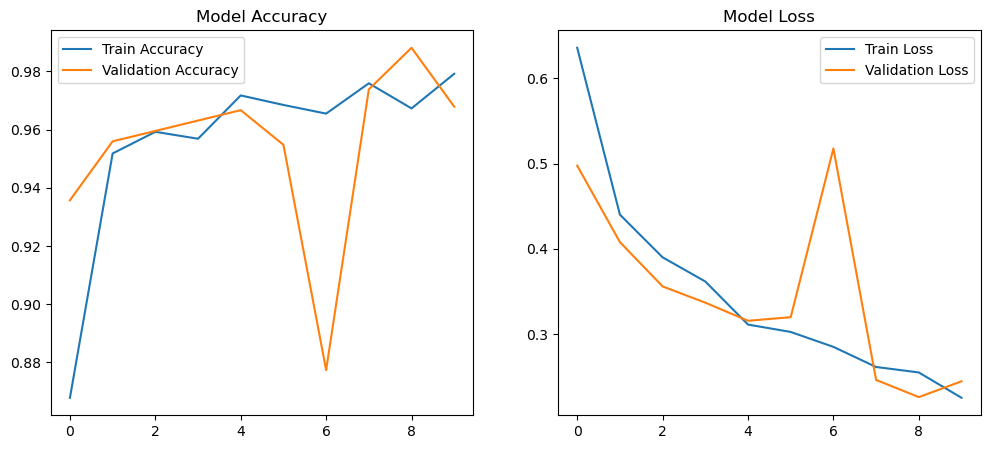

Found 4200 images belonging to 2 classes.
132/132 ━━━━━━━━━━━━━━━━━━━━ 1371s 10s/step - accuracy: 0.9981 - loss: 0.1686

Test Accuracy: 0.9898
Test Loss: 0.1901
27/27 ━━━━━━━━━━━━━━━━━━━━ 341s 13s/step

Updated Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       700
          TB       0.93      0.92      0.93       140

    accuracy                           0.98       840
   macro avg       0.96      0.95      0.96       840
weighted avg       0.98      0.98      0.98       840



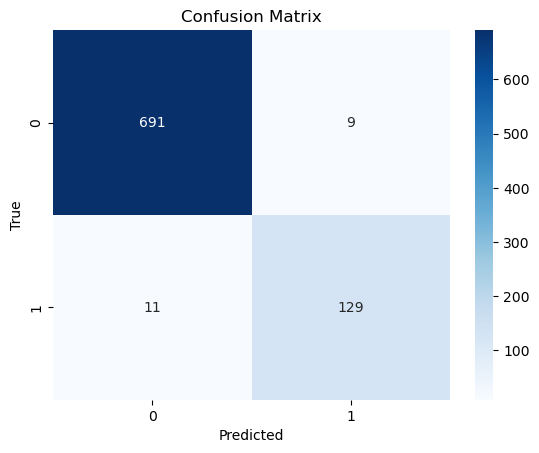

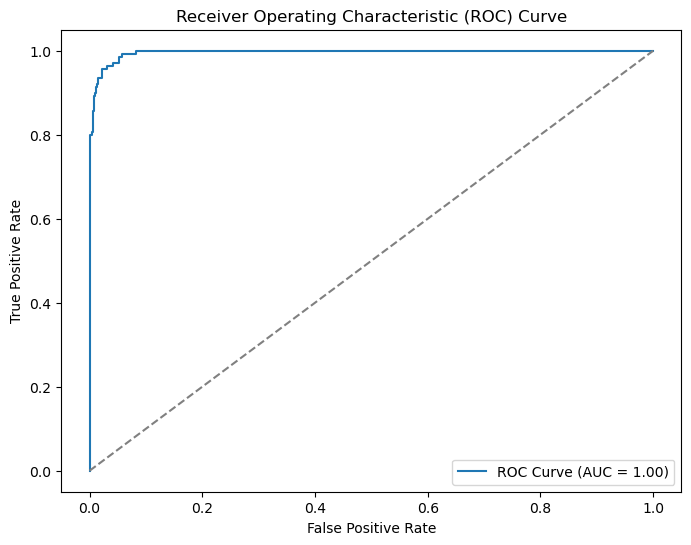

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# === Improved Data Augmentation ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,  # Increased augmentation
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Compute class weights for imbalance handling
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Updated Class Weights:", class_weight_dict)

# Load pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-4]:  # Fine-tuning last 4 layers
    layer.trainable = False

# Build the model with L2 regularization and dropout
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Define and compile the model
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict,
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === Evaluate Model on Test Data ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions and adjust threshold
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.4).astype(int)  # Lowering threshold to improve TB recall

# Classification Report
print("\nUpdated Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    base_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False,  # Important to maintain order for evaluation
    subset=None  # Ensure this loads the test data if stored separately
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 647s 6s/step - accuracy: 0.8245 - loss: 0.4802 - val_accuracy: 0.8333 - val_loss: 0.4499
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 607s 6s/step - accuracy: 0.8386 - loss: 0.4158 - val_accuracy: 0.8321 - val_loss: 0.4347
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 498s 5s/step - accuracy: 0.8679 - loss: 0.3363 - val_accuracy: 0.1881 - val_loss: 0.9953
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 460s 4s/step - accuracy: 0.9003 - loss: 0.2498 - val_accuracy: 0.8607 - val_loss: 0.3413
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 450s 4s/step - accuracy: 0.9021 - loss: 0.2690 - val_accuracy: 0.1714 - val_loss: 2.9968
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 489s 5s/step - accuracy: 0.9014 - loss: 0.2617 - val_accuracy: 0.8726 - val_loss: 0.2956
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 551s 5s/step - accuracy: 0.9128 - loss: 0.2372 - val_accuracy: 0.8571 - val_loss: 0.3262
Epoch 8/10
105

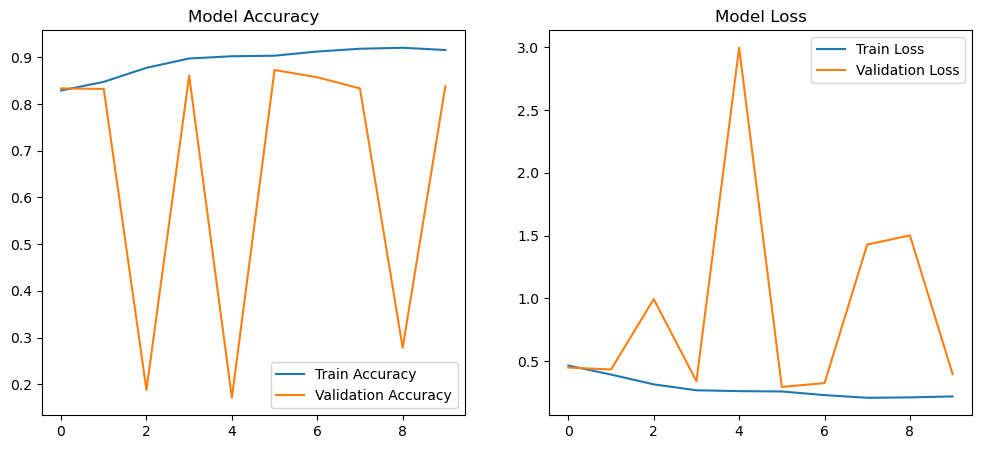

27/27 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step


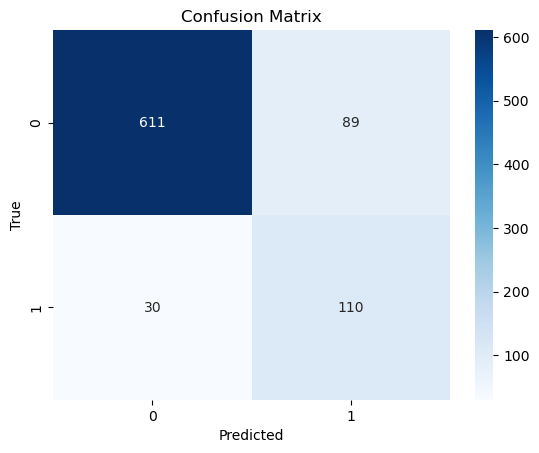


Classification Report:
               precision    recall  f1-score   support

      Normal       0.95      0.87      0.91       700
          TB       0.55      0.79      0.65       140

    accuracy                           0.86       840
   macro avg       0.75      0.83      0.78       840
weighted avg       0.89      0.86      0.87       840

F1-Score: 0.6490


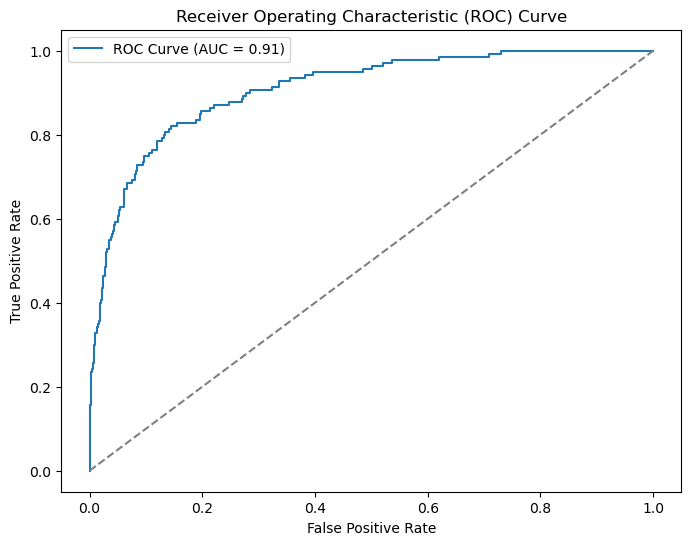

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers, then unfreeze top 10
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-10:]:  # Unfreeze last 10 layers
    layer.trainable = True

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

# Compile model (fixed optimizer issue)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# Extract and display F1-score
f1_score = report['TB']['f1-score']
print(f"F1-Score: {f1_score:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')  # Fixed closing parenthesis
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 445s 4s/step - accuracy: 0.8229 - loss: 0.4097 - val_accuracy: 0.8667 - val_loss: 0.3208
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - accuracy: 0.9199 - loss: 0.2126 - val_accuracy: 0.9095 - val_loss: 0.2074
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 464s 4s/step - accuracy: 0.9403 - loss: 0.1564 - val_accuracy: 0.9274 - val_loss: 0.1814
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 485s 5s/step - accuracy: 0.9509 - loss: 0.1375 - val_accuracy: 0.9250 - val_loss: 0.1816
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 430s 4s/step - accuracy: 0.9521 - loss: 0.1099 - val_accuracy: 0.9357 - val_loss: 0.1576
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.9579 - loss: 0.1040 - val_accuracy: 0.9607 - val_loss: 0.1082
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 456s 4s/step - accuracy: 0.9651 - loss: 0.1015 - val_accuracy: 0.9452 - val_loss: 0.1327
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 532s 5s/step - accuracy: 0.9717 - loss: 0.0877 - val_accuracy: 0.940

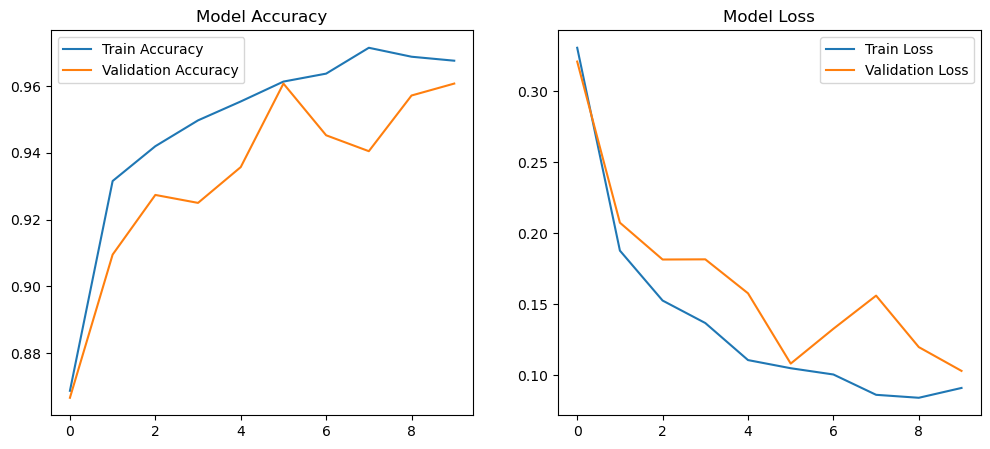

27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step


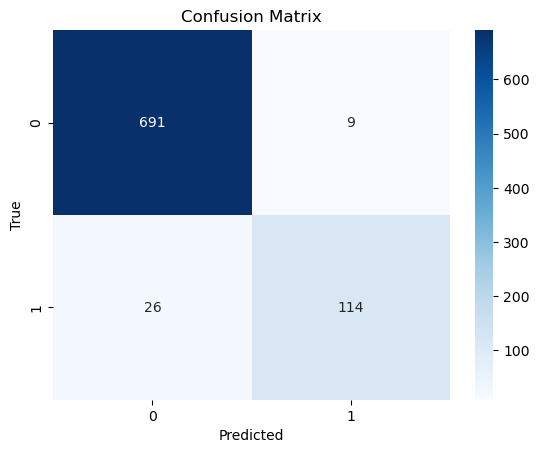


Classification Report:
               precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       700
          TB       0.93      0.81      0.87       140

    accuracy                           0.96       840
   macro avg       0.95      0.90      0.92       840
weighted avg       0.96      0.96      0.96       840



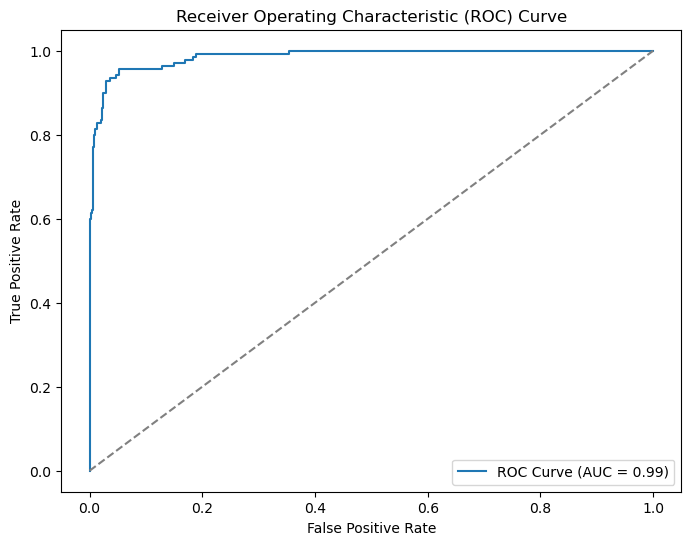

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last 4 layers of DenseNet121
for layer in base_model.layers[:-4]:  
    layer.trainable = False  

# Build the model using DenseNet121 as the base
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [10]:
# Load the test set
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    base_path,  # Change to your actual test folder if different
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Found 4200 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


132/132 ━━━━━━━━━━━━━━━━━━━━ 476s 4s/step - accuracy: 0.9951 - loss: 0.0134

Test Accuracy: 97.50%


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Found 4200 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 532s 5s/step - accuracy: 0.8061 - loss: 0.4367 - val_accuracy: 0.8702 - val_loss: 0.2861
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 501s 5s/step - accuracy: 0.9214 - loss: 0.2079 - val_accuracy: 0.8988 - val_loss: 0.2302
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 497s 5s/step - accuracy: 0.9486 - loss: 0.1384 - val_accuracy: 0.9333 - val_loss: 0.1658
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 533s 5s/step - accuracy: 0.9474 - loss: 0.1354 - val_accuracy: 0.9536 - val_loss: 0.1322
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 557s 5s/step - accuracy: 0.9571 - loss: 0.1101 - val_accuracy: 0.9393 - val_loss: 0.1336
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 622s 6s/step - accuracy: 0.9542 - loss: 0.1189 - val_accuracy: 0.9488 - val_loss: 0.1431
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 541s 5s/step - accuracy: 0.9606 - loss: 0.1116 - val_accuracy: 0.9464 - val_loss: 0.1176
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 562s 5s/step - accuracy: 0.9754 - loss: 0.0753 - val_accu

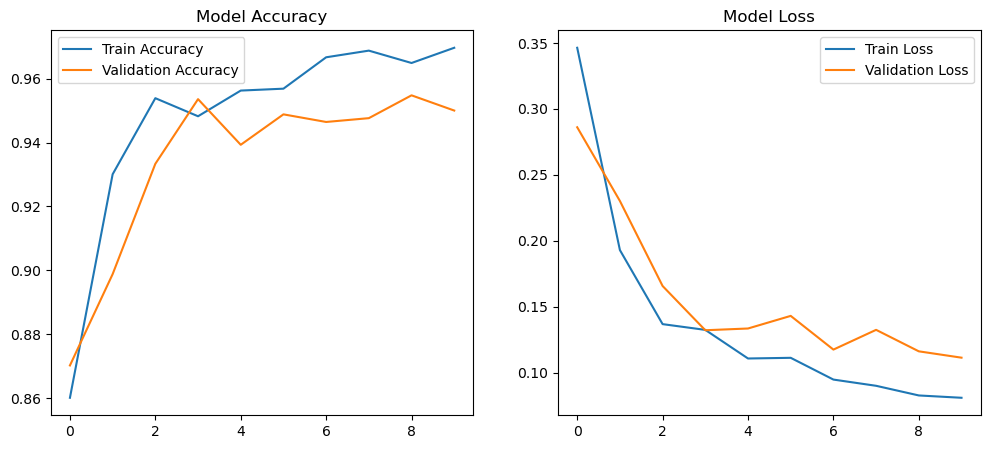

132/132 ━━━━━━━━━━━━━━━━━━━━ 528s 4s/step - accuracy: 0.9962 - loss: 0.0112
Test Accuracy: 0.9750
132/132 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step


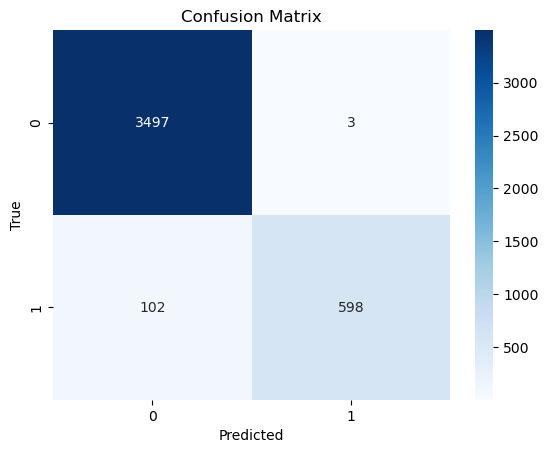


Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      1.00      0.99      3500
          TB       1.00      0.85      0.92       700

    accuracy                           0.97      4200
   macro avg       0.98      0.93      0.95      4200
weighted avg       0.98      0.97      0.97      4200



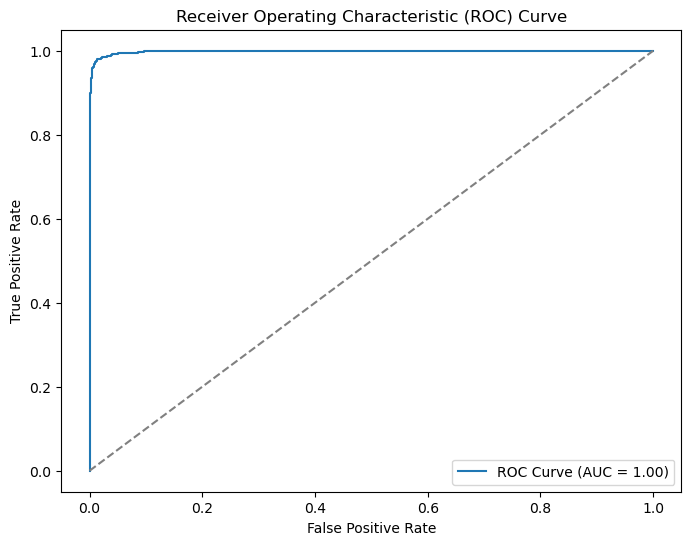

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load test set (assuming test images are stored in a separate folder inside base_path)
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Load pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tuning: Unfreeze last 4 layers of DenseNet121
for layer in base_model.layers[:-4]:  
    layer.trainable = False  

# Build the model using DenseNet121 as the base
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predictions on test data
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 775s 7s/step - accuracy: 0.8216 - loss: 0.4398 - val_accuracy: 0.8655 - val_loss: 0.2973
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 588s 6s/step - accuracy: 0.9212 - loss: 0.1876 - val_accuracy: 0.9250 - val_loss: 0.1765
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 573s 5s/step - accuracy: 0.9638 - loss: 0.0950 - val_accuracy: 0.9655 - val_loss: 0.0784
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 576s 5s/step - accuracy: 0.9731 - loss: 0.0850 - val_accuracy: 0.9786 - val_loss: 0.0670
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 580s 5s/step - accuracy: 0.9740 - loss: 0.0631 - val_accuracy: 0.9714 - val_loss: 0.0646
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 561s 5s/step - accuracy: 0.9820 - loss: 0.0532 - val_accuracy: 0.9726 - val_loss: 0.0809
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 469s 4s/step - accuracy: 0.9835 - loss: 0.0475 - val_accuracy: 0.9762 - val_loss: 0.0587
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 468s 4s/step - accuracy: 0.9906 - loss: 0.0302 - val_accuracy: 0.979

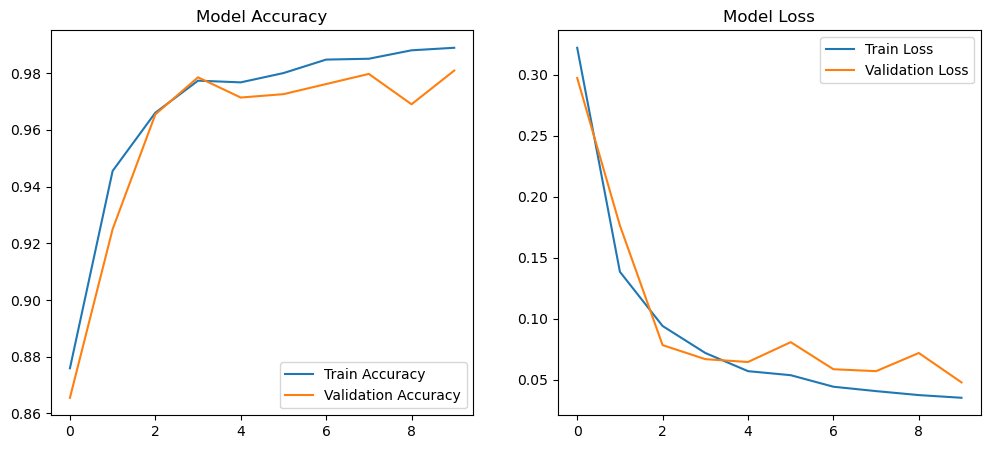

27/27 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.9962 - loss: 0.0089
Test Accuracy: 0.9833
27/27 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step


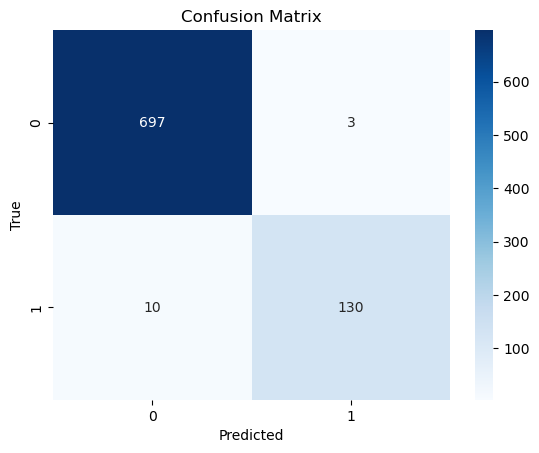


Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       700
          TB       0.98      0.93      0.95       140

    accuracy                           0.98       840
   macro avg       0.98      0.96      0.97       840
weighted avg       0.98      0.98      0.98       840



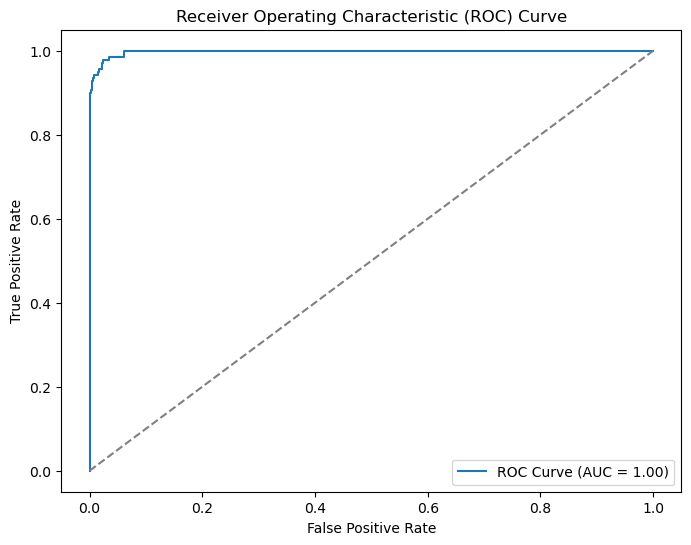

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation and normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation (used as test set)
)

# Load train and validation (test) sets
train_generator = datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)

test_generator = datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune by unfreezing last few layers
for layer in base_model.layers[:-10]:  
    layer.trainable = False  

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model
history = model.fit(train_generator, validation_data=test_generator, epochs=10, callbacks=[early_stop])

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predictions on test data
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Class Weights: {0: 0.6, 1: 3.0}
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 479s 4s/step - accuracy: 0.5485 - loss: 0.7138 - val_accuracy: 0.8333 - val_loss: 0.5443 - learning_rate: 1.0000e-04
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 505s 5s/step - accuracy: 0.8013 - loss: 0.4482 - val_accuracy: 0.8333 - val_loss: 0.6584 - learning_rate: 1.0000e-04
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8586 - loss: 0.3773
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
105/105 ━━━━━━━━━━━━━━━━━━━━ 531s 5s/step - accuracy: 0.8587 - loss: 0.3769 - val_accuracy: 0.8333 - val_loss: 0.8951 - learning_rate: 1.0000e-04
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 537s 5s/step - accuracy: 0.8963 - loss: 0.3029 - val_accuracy: 0.8786 - val_loss: 0.3039 - learning_rate: 2.0000e-05
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 521s 5s/step - accuracy: 0.8899 - loss: 0.2870 - val_accuracy: 0.5643 - val_loss: 0.8583 - learning_rate: 2.0000e-05
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9087 - los

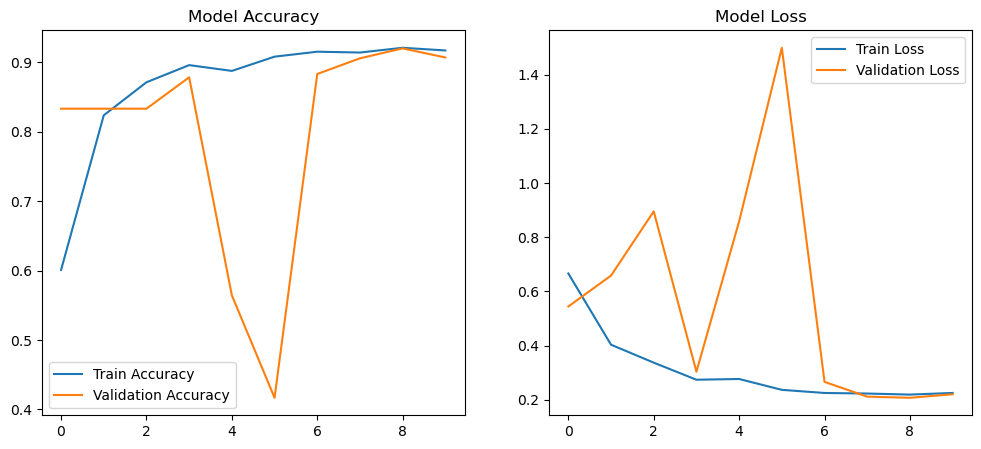

27/27 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.9547 - loss: 0.1132
Validation Accuracy: 0.9202
27/27 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step


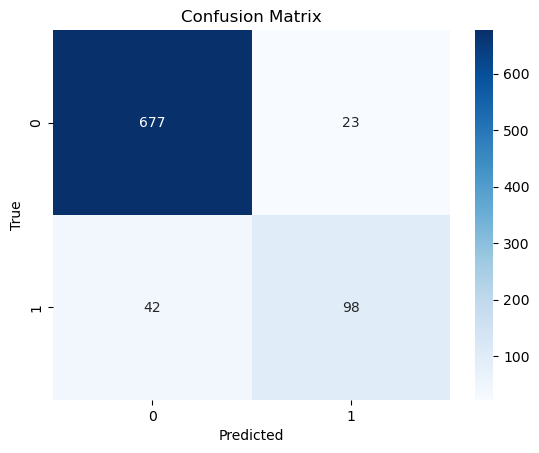


Classification Report:
               precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       700
          TB       0.81      0.70      0.75       140

    accuracy                           0.92       840
   macro avg       0.88      0.83      0.85       840
weighted avg       0.92      0.92      0.92       840



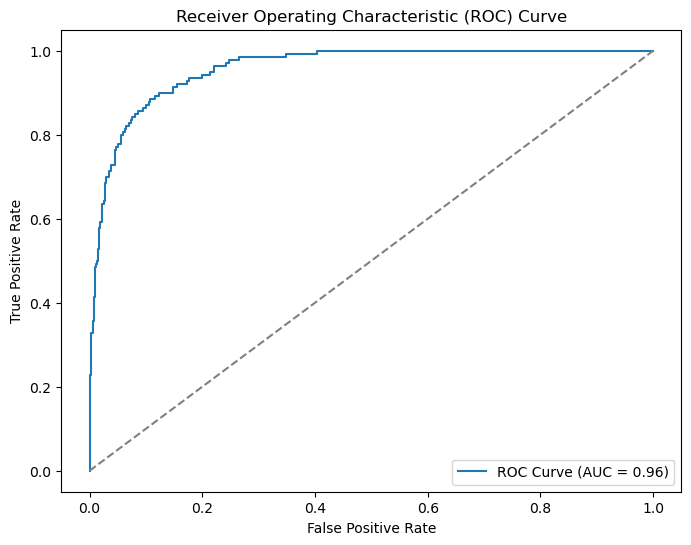

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation (simplified)
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  
)

# Load train and validation sets
train_generator = datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)

val_generator = datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Calculate class weights to handle imbalance
class_labels = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(class_labels), y=class_labels)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class Weights:", class_weight_dict)

# Load pre-trained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-tune last 10 layers
for layer in base_model.layers[:-10]:  
    layer.trainable = False  

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Callbacks to improve training
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)

# Train model with class weights
history = model.fit(train_generator, validation_data=val_generator, epochs=10,
                    callbacks=[early_stop, reduce_lr], class_weight=class_weight_dict)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model on validation set
val_loss, val_accuracy = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_accuracy:.4f}')

# Predictions
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Epoch 1/20


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 436s 4s/step - accuracy: 0.7953 - loss: 0.5065 - val_accuracy: 0.8333 - val_loss: 0.4540
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 425s 4s/step - accuracy: 0.8521 - loss: 0.3925 - val_accuracy: 0.8333 - val_loss: 0.4988
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 643s 6s/step - accuracy: 0.8825 - loss: 0.3140 - val_accuracy: 0.8500 - val_loss: 0.3926
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 630s 6s/step - accuracy: 0.8765 - loss: 0.3300 - val_accuracy: 0.1881 - val_loss: 1.1818
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 632s 6s/step - accuracy: 0.8905 - loss: 0.2814 - val_accuracy: 0.6452 - val_loss: 0.6385
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 673s 6s/step - accuracy: 0.9018 - loss: 0.2335 - val_accuracy: 0.8595 - val_loss: 0.3761
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 668s 6s/step - accuracy: 0.9076 - loss: 0.2487 - val_accuracy: 0.8738 - val_loss: 0.3460
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 590s 6s/step - accuracy: 0.9153 - loss: 0.2302 - val_accuracy: 0.840

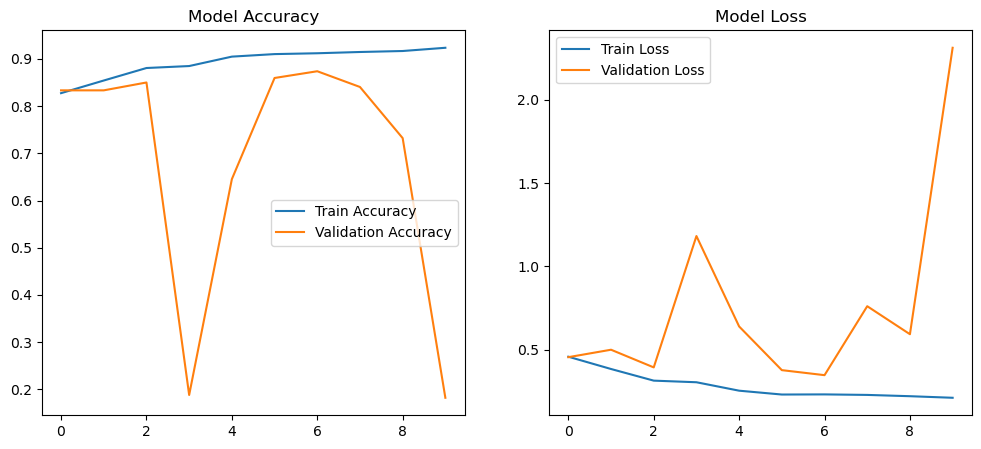

27/27 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step


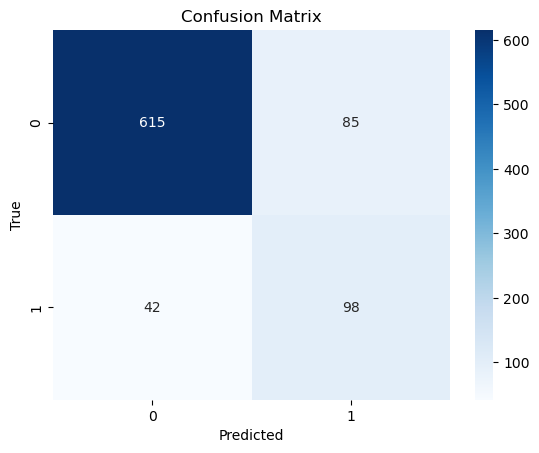


Classification Report:
               precision    recall  f1-score   support

      Normal       0.94      0.88      0.91       700
          TB       0.54      0.70      0.61       140

    accuracy                           0.85       840
   macro avg       0.74      0.79      0.76       840
weighted avg       0.87      0.85      0.86       840

F1-Score: 0.6068


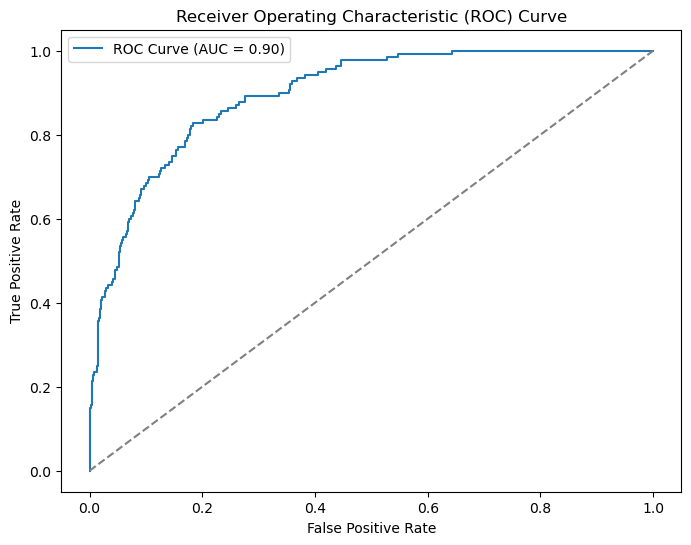

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# Load pre-trained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers, then unfreeze top 10
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-10:]:  # Unfreeze last 10 layers
    layer.trainable = True

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),  
    Dropout(0.5),
    Dense(256, activation='relu'),  
    Dropout(0.3),
    Dense(1, activation='sigmoid')  
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Implement Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Train model with early stopping
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # Increased to allow for early stopping
    callbacks=[early_stopping]
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# Evaluate model
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# Extract and display F1-score
f1_score = report['TB']['f1-score']
print(f"F1-Score: {f1_score:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [2]:
import os
import shutil
import random

# Define paths
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'val')
test_path = os.path.join(base_path, 'test')

# Define class names
classes = ['NORMAL', 'TUBERCULOSIS']

# Create train, val, test folders
for folder in [train_path, val_path, test_path]:
    os.makedirs(folder, exist_ok=True)
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

# Function to split data
def split_data(source_dir, train_dir, val_dir, test_dir, train_split=0.7, val_split=0.15):
    files = os.listdir(source_dir)
    random.shuffle(files)  # Shuffle for randomness

    train_size = int(len(files) * train_split)
    val_size = int(len(files) * val_split)

    train_files = files[:train_size]
    val_files = files[train_size:train_size + val_size]
    test_files = files[train_size + val_size:]

    for file in train_files:
        shutil.move(os.path.join(source_dir, file), os.path.join(train_dir, file))
    for file in val_files:
        shutil.move(os.path.join(source_dir, file), os.path.join(val_dir, file))
    for file in test_files:
        shutil.move(os.path.join(source_dir, file), os.path.join(test_dir, file))

# Split data for both classes
for cls in classes:
    split_data(
        source_dir=os.path.join(base_path, cls),
        train_dir=os.path.join(train_path, cls),
        val_dir=os.path.join(val_path, cls),
        test_dir=os.path.join(test_path, cls)
    )

print("Dataset split completed!")


Dataset split completed!


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8341 - loss: 0.4367 - val_accuracy: 0.8778 - val_loss: 0.2289 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9269 - loss: 0.1710 - val_accuracy: 0.9159 - val_loss: 0.2121 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9622 - loss: 0.1173 - val_accuracy: 0.9508 - val_loss: 0.1194 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9643 - loss: 0.0969 - val_accuracy: 0.9460 - val_loss: 0.1365 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9653 - loss: 0.0886 - val_accuracy: 0.9651 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9813 - loss: 0.0525 - val_accuracy: 0.9698 - val_loss: 0.0842 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9872 - loss: 0.0462 - val_acc

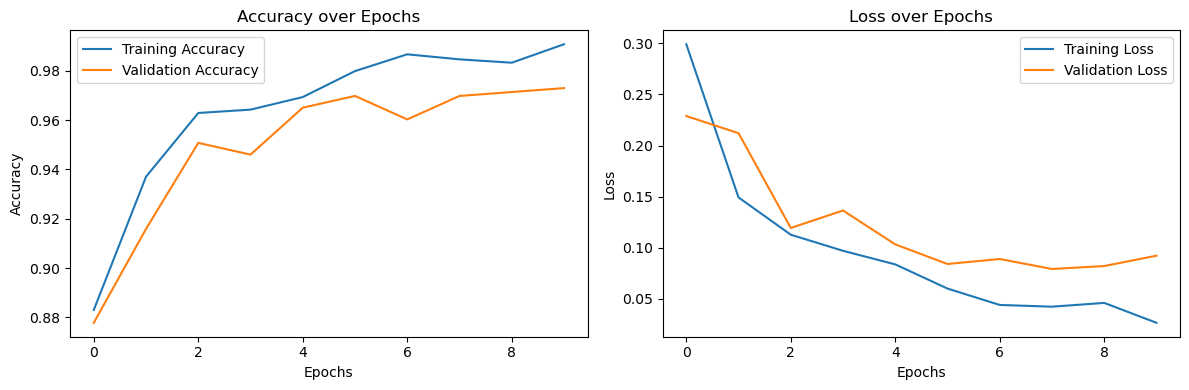

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Step 1: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPool2D(pool_size=(2, 2)),
    
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification (Tuberculosis vs. Normal)
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 2: Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 3: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 4: Generate classification report and confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 5: Visualize training results
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
y_pred_probs = model.predict(X_test)  # Predicted probabilities for the test set

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step


In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


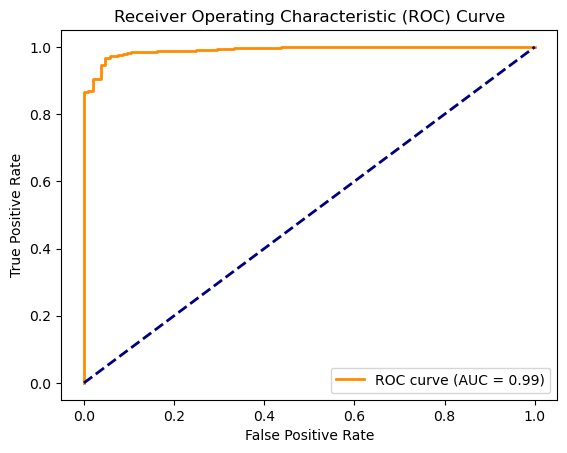

In [14]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Calculate the Area Under the Curve (AUC) score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


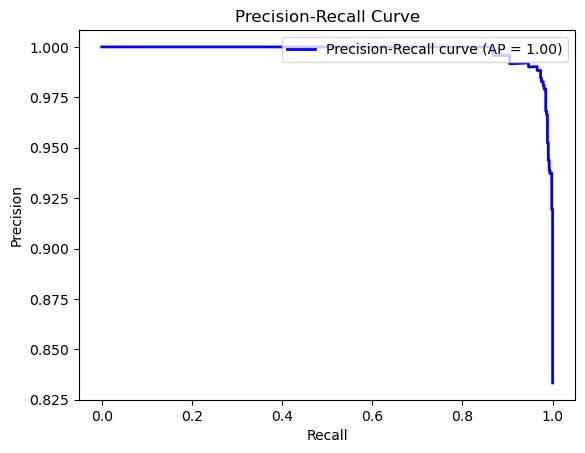

In [15]:
# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Calculate Average Precision (AP) score
average_precision = average_precision_score(y_test, y_pred_probs)

# Plot the Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()


In [16]:
y_pred_probs = model.predict(X_test)  # Predicted probabilities for the test set


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 259ms/step


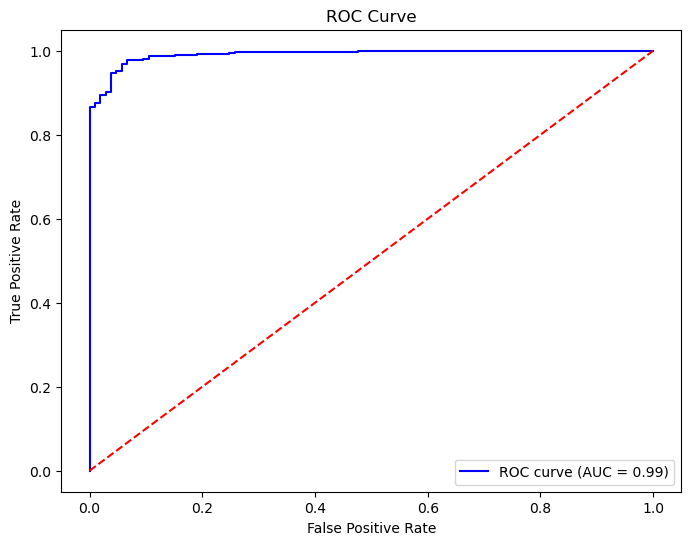

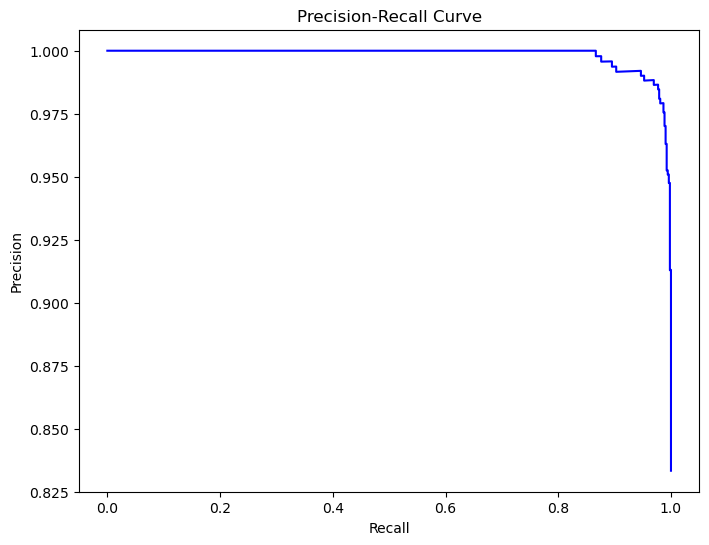

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

# Make predictions on test data
y_pred_prob = model.predict(X_test)  # This returns probabilities for each class

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')  # Diagonal line (no discrimination)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


In [17]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


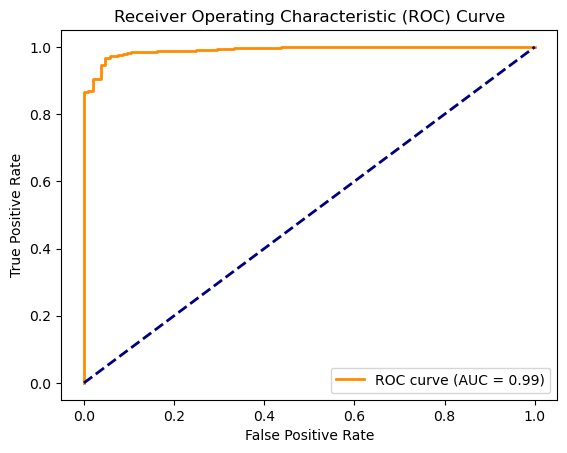

In [18]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Calculate the Area Under the Curve (AUC) score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


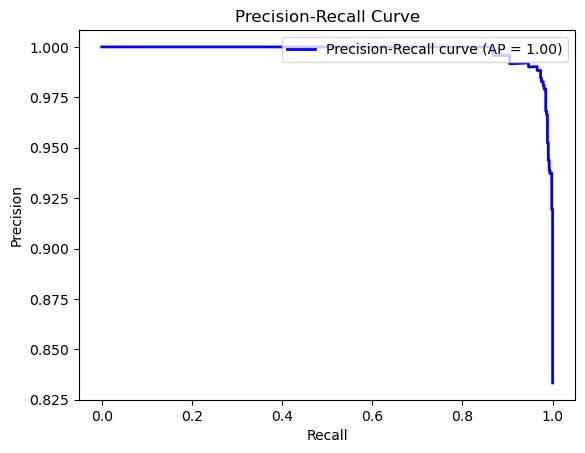

In [19]:
# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Calculate Average Precision (AP) score
average_precision = average_precision_score(y_test, y_pred_probs)

# Plot the Precision-Recall curve
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()


Train shape: (2940, 128, 128, 1), Train labels: (2940,)
Validation shape: (420, 128, 128, 1), Validation labels: (420,)
Test shape: (840, 128, 128, 1), Test labels: (840,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8200 - loss: 0.4849 - val_accuracy: 0.9262 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9306 - loss: 0.1631 - val_accuracy: 0.9595 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9500 - loss: 0.1467 - val_accuracy: 0.9667 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9659 - loss: 0.1012 - val_accuracy: 0.9524 - val_loss: 0.1078 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9687 - loss: 0.0822 - val_accuracy: 0.9667 - val_loss: 0.0748 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9756 - loss: 0.0756 - val_accuracy: 0.9714 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9847 - loss: 0.0488 - val_acc

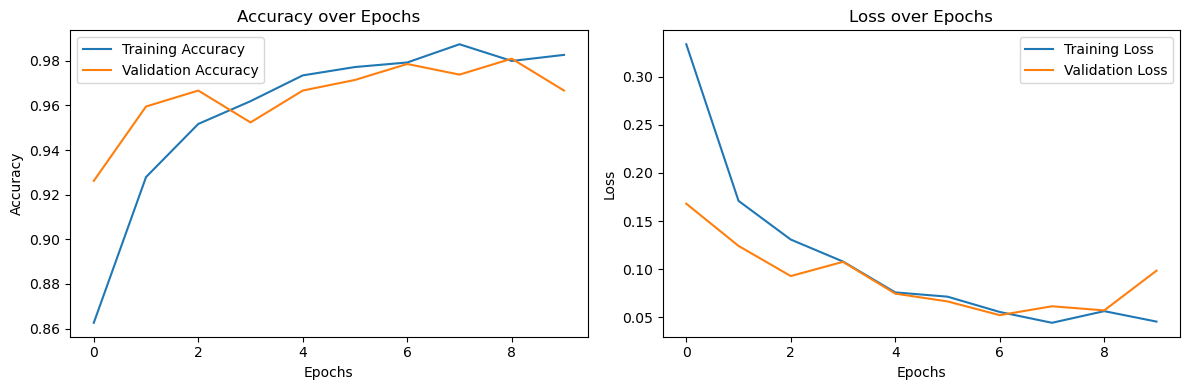

In [15]:
# Import necessary libraries
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Define dataset path
base_dir = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Define categories
categories = ["Normal", "Tuberculosis"]
img_size = 128  # Resize images

# Load dataset
data = []
labels = []

for category in categories:
    path = os.path.join(base_dir, category)
    class_num = categories.index(category)  # 0 = Normal, 1 = Tuberculosis

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(class_num)

# Convert to numpy arrays
data = np.array(data).reshape(-1, img_size, img_size, 1) / 255.0  # Normalize images
labels = np.array(labels)

# Split dataset (3360 train, 840 test to match other models)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=840/4200, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=420/3360, random_state=42, stratify=y_train)

print(f"Train shape: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Validation shape: {X_val.shape}, Validation labels: {y_val.shape}")
print(f"Test shape: {X_test.shape}, Test labels: {y_test.shape}")

# Build the CNN model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification (Normal vs. TB)
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Learning rate adjustment
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Evaluate on Test Data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification Report & Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualize Training Results
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Train shape: (2940, 128, 128, 1), Train labels: (2940,)
Validation shape: (420, 128, 128, 1), Validation labels: (420,)
Test shape: (840, 128, 128, 1), Test labels: (840,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8270 - loss: 0.4679 - val_accuracy: 0.9333 - val_loss: 0.1886 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9451 - loss: 0.1581 - val_accuracy: 0.9524 - val_loss: 0.1102 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9662 - loss: 0.0989 - val_accuracy: 0.9571 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9684 - loss: 0.0841 - val_accuracy: 0.9738 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9721 - loss: 0.0732 - val_accuracy: 0.9548 - val_loss: 0.1110 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9720 - loss: 0.0747 - val_accuracy: 0.9714 - val_loss: 0.0801 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9856 - loss: 0.0446
Epoch 7: Re

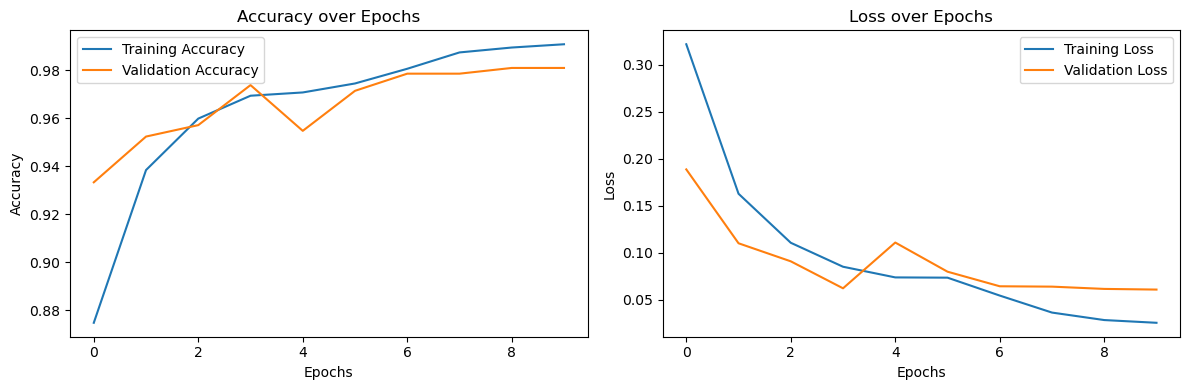

In [16]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Set dataset path
dataset_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Classes
categories = ["Normal", "Tuberculosis"]

# Image size
img_size = 128

# Load dataset
data = []
labels = []

for category in categories:
    class_index = categories.index(category)  # Normal: 0, Tuberculosis: 1
    folder_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        img = cv2.resize(img, (img_size, img_size))  # Resize

        data.append(img)
        labels.append(class_index)

# Convert lists to numpy arrays
data = np.array(data).reshape(-1, img_size, img_size, 1)  # Reshape for CNN
labels = np.array(labels)

# Normalize images (scale between 0 and 1)
data = data / 255.0

# Split dataset to match other models (3360 train, 840 test)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=840/4200, random_state=42, stratify=labels)

# Optional: Split train into train & validation (keeping 3360 train + val)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=420/3360, random_state=42, stratify=y_train)

print(f"Train shape: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Validation shape: {X_val.shape}, Validation labels: {y_val.shape}")
print(f"Test shape: {X_test.shape}, Test labels: {y_test.shape}")

# Step 1: Build CNN Model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 2: Train Model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 3: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 4: Classification Report & Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 5: Plot Accuracy & Loss
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Train shape: (2940, 128, 128, 1), Train labels: (2940,)
Validation shape: (420, 128, 128, 1), Validation labels: (420,)
Test shape: (840, 128, 128, 1), Test labels: (840,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8205 - loss: 0.4394 - val_accuracy: 0.9381 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9294 - loss: 0.1712 - val_accuracy: 0.9595 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9550 - loss: 0.1160 - val_accuracy: 0.9643 - val_loss: 0.0945 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9701 - loss: 0.0887 - val_accuracy: 0.9714 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9681 - loss: 0.0833 - val_accuracy: 0.9595 - val_loss: 0.1022 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9758 - loss: 0.0730 - val_accuracy: 0.9833 - val_loss: 0.0593 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9858 - loss: 0.0385 - val_acc

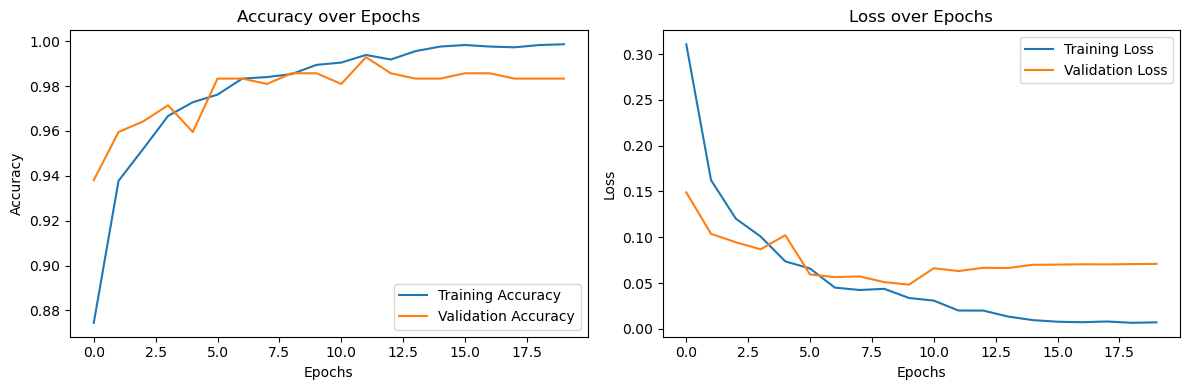

In [20]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Set dataset path
dataset_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Classes
categories = ["Normal", "Tuberculosis"]

# Image size
img_size = 128

# Load dataset
data = []
labels = []

for category in categories:
    class_index = categories.index(category)  # Normal: 0, Tuberculosis: 1
    folder_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        img = cv2.resize(img, (img_size, img_size))  # Resize

        data.append(img)
        labels.append(class_index)

# Convert lists to numpy arrays
data = np.array(data).reshape(-1, img_size, img_size, 1)  # Reshape for CNN
labels = np.array(labels)

# Normalize images (scale between 0 and 1)
data = data / 255.0

# Split dataset to match other models (3360 train, 840 test)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=840/4200, random_state=42, stratify=labels)

# Optional: Split train into train & validation (keeping 3360 train + val)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=420/3360, random_state=42, stratify=y_train)

print(f"Train shape: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Validation shape: {X_val.shape}, Validation labels: {y_val.shape}")
print(f"Test shape: {X_test.shape}, Test labels: {y_test.shape}")

# Step 1: Build CNN Model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 2: Train Model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 3: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 4: Classification Report & Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 5: Plot Accuracy & Loss
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Train shape: (2940, 128, 128, 1), Train labels: (2940,)
Validation shape: (420, 128, 128, 1), Validation labels: (420,)
Test shape: (840, 128, 128, 1), Test labels: (840,)
Train class distribution: {0: 2450, 1: 490}
Validation class distribution: {0: 350, 1: 70}
Test class distribution: {0: 700, 1: 140}


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8380 - loss: 0.4118 - val_accuracy: 0.9310 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9454 - loss: 0.1497 - val_accuracy: 0.9667 - val_loss: 0.0942 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9616 - loss: 0.1058 - val_accuracy: 0.9714 - val_loss: 0.0947 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9718 - loss: 0.0843 - val_accuracy: 0.9667 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9779 - loss: 0.0647 - val_accuracy: 0.9595 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9766 - loss: 0.0590 - val_accuracy: 0.9833 - val_loss: 0.0562 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9860 - loss: 0.0423 - val_accur

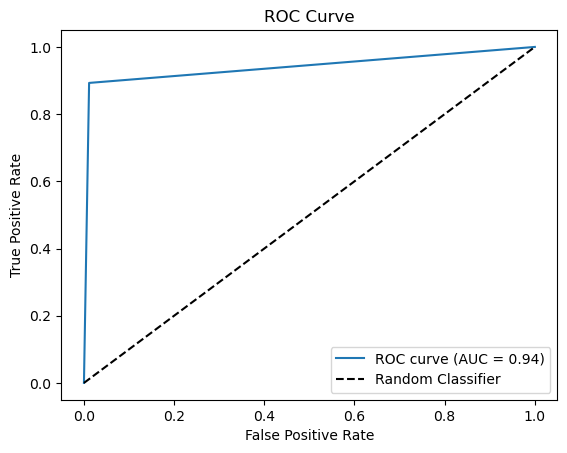

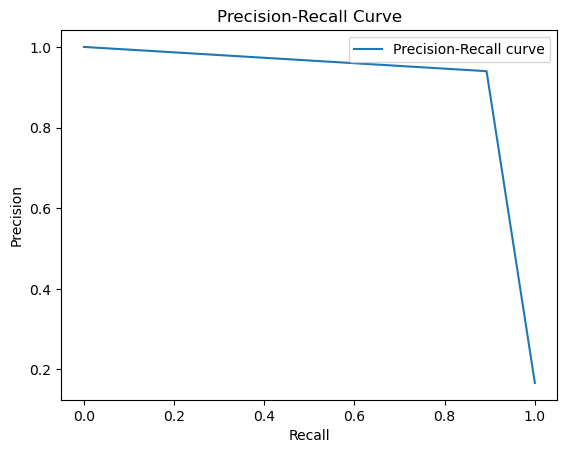

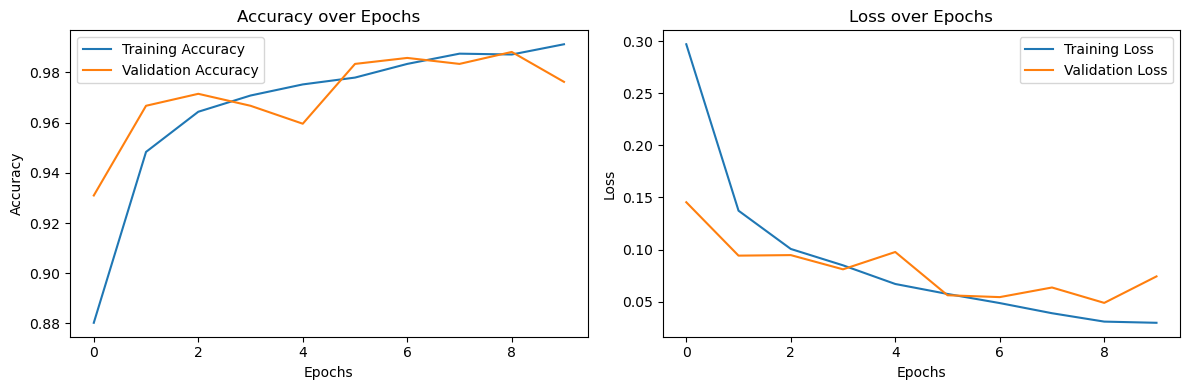

In [17]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Set dataset path
dataset_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Classes
categories = ["Normal", "Tuberculosis"]

# Image size
img_size = 128

# Load dataset
data = []
labels = []

for category in categories:
    class_index = categories.index(category)  # Normal: 0, Tuberculosis: 1
    folder_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        img = cv2.resize(img, (img_size, img_size))  # Resize

        data.append(img)
        labels.append(class_index)

# Convert lists to numpy arrays
data = np.array(data).reshape(-1, img_size, img_size, 1)  # Reshape for CNN
labels = np.array(labels)

# Normalize images (scale between 0 and 1)
data = data / 255.0

# ✅ Step 1: First, split into Train (3360) and Test (840) to match other models
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=840/4200, random_state=42, stratify=labels
)

# ✅ Step 2: Optional Validation Split (Train = 2940, Validation = 420)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=420/3360, random_state=42, stratify=y_train
)

# ✅ Final dataset sizes:
print(f"Train shape: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Validation shape: {X_val.shape}, Validation labels: {y_val.shape}")
print(f"Test shape: {X_test.shape}, Test labels: {y_test.shape}")

# ✅ Confirm class balance
train_unique, train_counts = np.unique(y_train, return_counts=True)
val_unique, val_counts = np.unique(y_val, return_counts=True)
test_unique, test_counts = np.unique(y_test, return_counts=True)

print(f"Train class distribution: {dict(zip(train_unique, train_counts))}")
print(f"Validation class distribution: {dict(zip(val_unique, val_counts))}")
print(f"Test class distribution: {dict(zip(test_unique, test_counts))}")

# Step 1: Build CNN Model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile Model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 2: Train Model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 3: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 4: Classification Report & Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 5: Plot Accuracy & Loss
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation (same as VGG16)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# === ✅ BUILD CUSTOM CNN MODEL ===
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# Evaluate test dataset
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Evaluate model on validation data
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=['Normal', 'TB'], output_dict=True)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,528,577 (169.86 MB)

...

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


105/105 ━━━━━━━━━━━━━━━━━━━━ 459s 4s/step - accuracy: 0.8563 - loss: 0.7278 - val_accuracy: 0.1667 - val_loss: 4.5760
Epoch 2/10
 89/105 ━━━━━━━━━━━━━━━━━━━━ 1:04 4s/step - accuracy: 0.9264 - loss: 0.4603

KeyboardInterrupt: 

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# Set base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Data augmentation (same as VGG16)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Load train and validation sets
train_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='training', shuffle=True)
val_generator = train_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation', shuffle=False)

# === ✅ BUILD CUSTOM CNN MODEL ===
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4, decay=1e-6), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train model
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# === ADD TEST DATASET ===
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    base_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)

# ✅ Evaluate test dataset and PRINT TEST ACCURACY
test_loss, test_accuracy = model.evaluate(test_generator)
print("\n=== TEST RESULTS ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# ✅ Add test accuracy to training history plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Test Accuracy: {test_accuracy:.4f}')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.4f}')
plt.legend()
plt.title('Model Loss')
plt.show()

# === Evaluate model on validation data ===
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


Found 3360 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,528,577 (169.86 MB)

 Trainable params: 44,528,129 (169.86 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8610 - loss: 0.7042

KeyboardInterrupt: 

Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8205 - loss: 0.5174 - val_accuracy: 0.8952 - val_loss: 0.2350 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8768 - loss: 0.2876 - val_accuracy: 0.8730 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8921 - loss: 0.2742 - val_accuracy: 0.9222 - val_loss: 0.1860 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8986 - loss: 0.2411 - val_accuracy: 0.8952 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9104 - loss: 0.2202 - val_accuracy: 0.9079 - val_loss: 0.2160 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8999 - loss: 0.2520
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
92/92 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9000 - loss: 0.2518 - val_accuracy: 0.9079

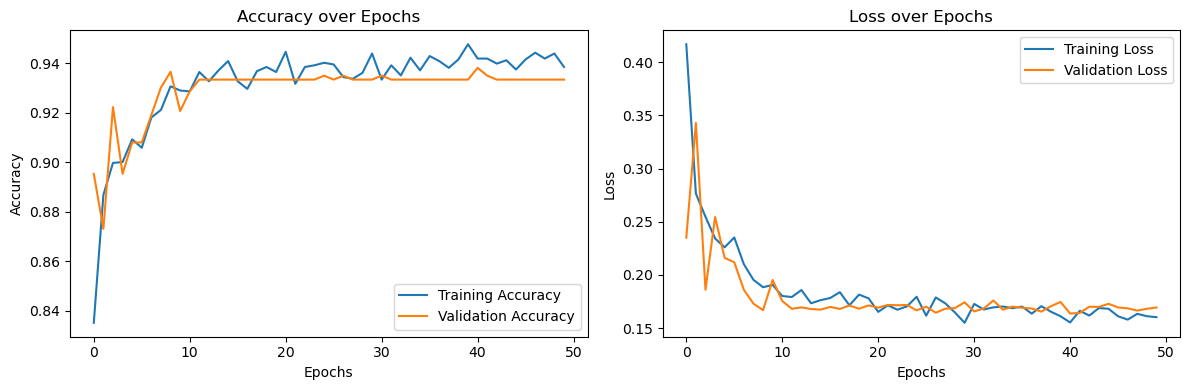

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPool2D(pool_size=(2, 2)),
    
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 6: Train the model for 50 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=50,  # Training for 50 epochs
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Confusion Matrix and Classification Report
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 9: Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 264ms/step


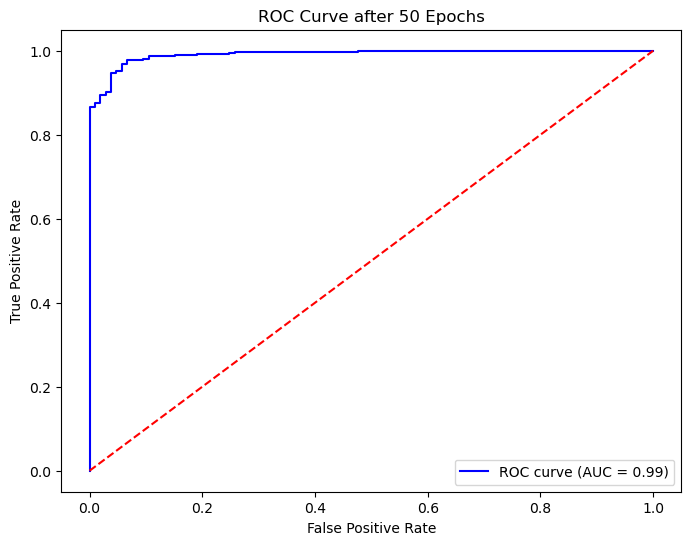

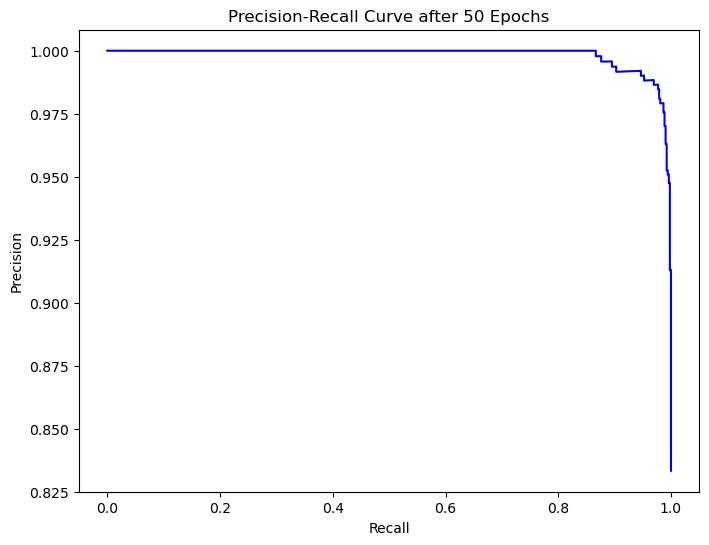

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

# Make predictions on test data
y_pred_prob_50 = model.predict(X_test)  # This returns probabilities for each class

# ROC Curve for 50 epochs
fpr_50, tpr_50, _ = roc_curve(y_test, y_pred_prob_50)
roc_auc_50 = auc(fpr_50, tpr_50)

# Plot ROC Curve for 50 epochs
plt.figure(figsize=(8, 6))
plt.plot(fpr_50, tpr_50, color='b', label=f'ROC curve (AUC = {roc_auc_50:.2f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')  # Diagonal line (no discrimination)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve after 50 Epochs')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve for 50 epochs
precision_50, recall_50, _ = precision_recall_curve(y_test, y_pred_prob_50)

# Plot Precision-Recall Curve for 50 epochs
plt.figure(figsize=(8, 6))
plt.plot(recall_50, precision_50, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve after 50 Epochs')
plt.show()


Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,820,353 (56.54 MB)

 Trainable params: 14,820,353 (56.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7839 - loss: 0.5161 - val_accuracy: 0.9032 - val_loss: 0.2548 - learning_rate: 0.0010
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8769 - loss: 0.2960 - val_accuracy: 0.9063 - val_loss: 0.2096 - learning_rate: 0.0010
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.8946 - loss: 0.2586 - val_accuracy: 0.9270 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8975 - loss: 0.2499 - val_accuracy: 0.9270 - val_loss: 0.1750 - learning_rate: 0.0010
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9108 - loss: 0.2238 - val_accuracy: 0.9190 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9061 - loss: 0.2492 - val_accuracy: 0.9222 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9199 - loss: 0.2030 - val_accuracy

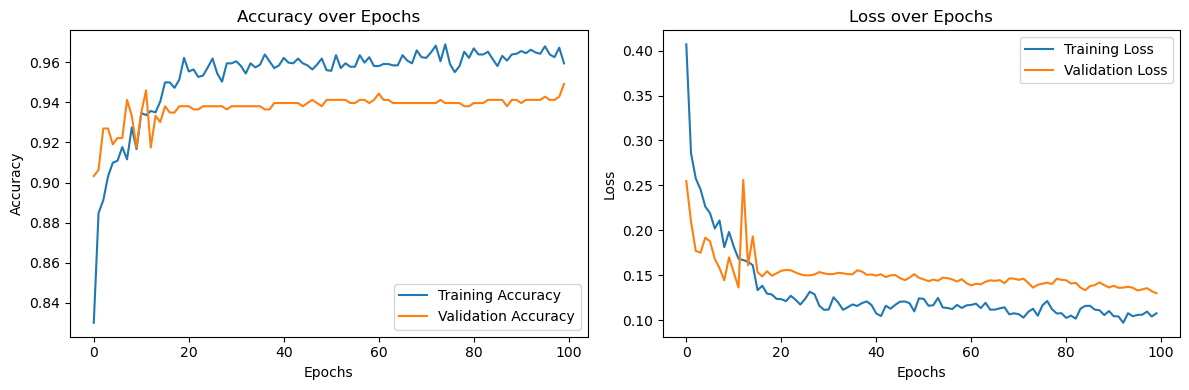

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPool2D(pool_size=(2, 2)),
    
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 6: Train the model for 100 epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=100,  # Training for 100 epochs
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Confusion Matrix and Classification Report
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 9: Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step


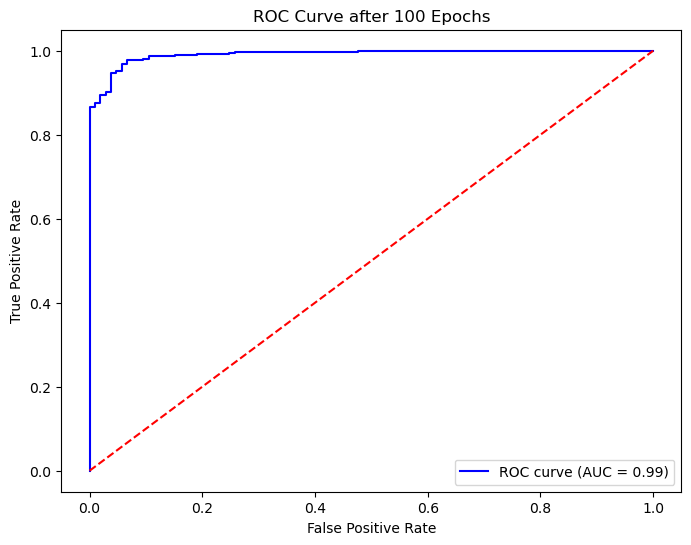

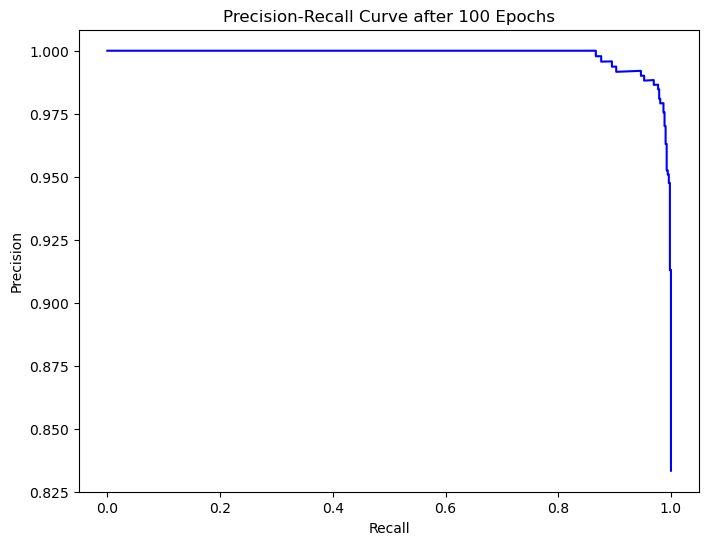

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Make predictions on test data after 100 epochs
y_pred_prob_100 = model.predict(X_test)  # This returns probabilities for each class

# ROC Curve for 100 epochs
fpr_100, tpr_100, _ = roc_curve(y_test, y_pred_prob_100)
roc_auc_100 = auc(fpr_100, tpr_100)

# Plot ROC Curve for 100 epochs
plt.figure(figsize=(8, 6))
plt.plot(fpr_100, tpr_100, color='b', label=f'ROC curve (AUC = {roc_auc_100:.2f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')  # Diagonal line (no discrimination)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve after 100 Epochs')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve for 100 epochs
precision_100, recall_100, _ = precision_recall_curve(y_test, y_pred_prob_100)

# Plot Precision-Recall Curve for 100 epochs
plt.figure(figsize=(8, 6))
plt.plot(recall_100, precision_100, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve after 100 Epochs')
plt.show()



Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,821,121 (56.54 MB)

 Trainable params: 14,820,737 (56.54 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.8038 - loss: 13.5710 - val_accuracy: 0.1841 - val_loss: 12.5374 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.8068 - loss: 10.5189 - val_accuracy: 0.1667 - val_loss: 23.7106 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8570 - loss: 6.4429 - val_accuracy: 0.8333 - val_loss: 9.0801 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.8460 - loss: 5.2615 - val_accuracy: 0.8365 - val_loss: 3.7946 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.8417 - loss: 4.7282 - val_accuracy: 0.8571 - val_loss: 3.9418 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.8608 - loss: 3.2700 - val_accuracy: 0.8238 - val_loss: 2.4911 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.8729 - loss: 2.3946 - val_accuracy: 

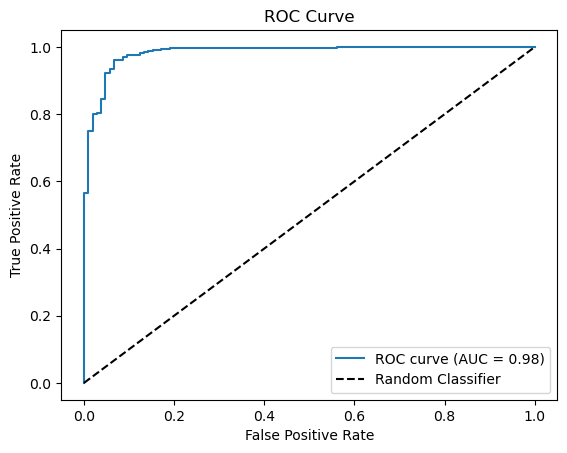

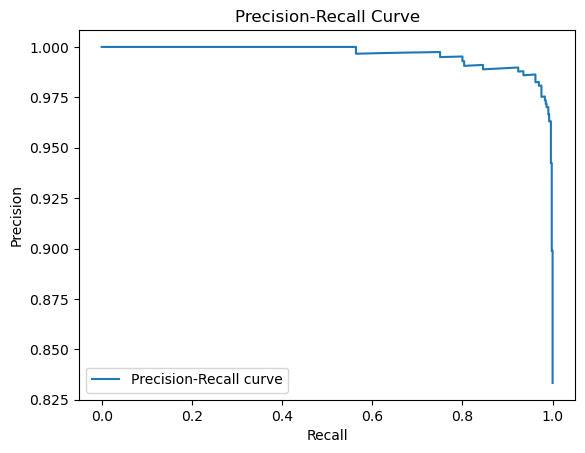

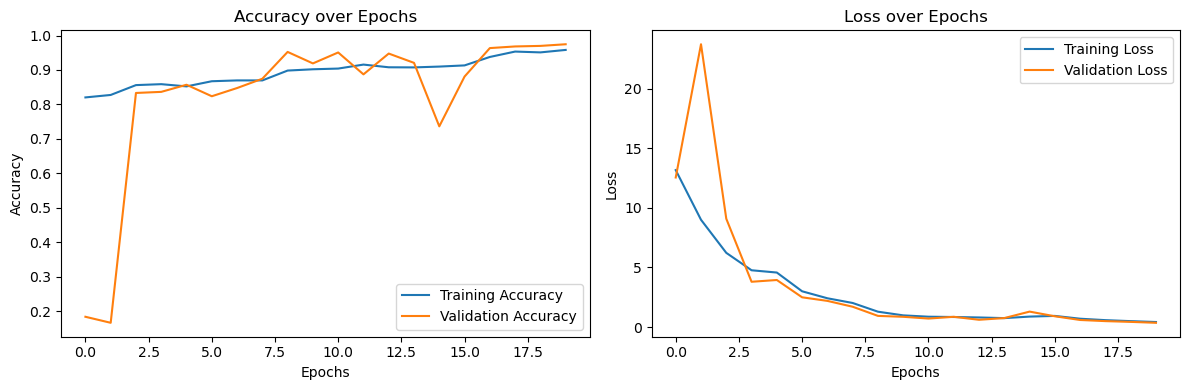

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report and Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,821,121 (56.54 MB)

 Trainable params: 14,820,737 (56.54 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8060 - loss: 11.7096 - val_accuracy: 0.8333 - val_loss: 8.0674 - learning_rate: 0.0010
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.8485 - loss: 8.6280 - val_accuracy: 0.6921 - val_loss: 6.8703 - learning_rate: 0.0010
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.8604 - loss: 6.4992 - val_accuracy: 0.6921 - val_loss: 6.9175 - learning_rate: 0.0010
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.8526 - loss: 5.4271 - val_accuracy: 0.8397 - val_loss: 5.7498 - learning_rate: 0.0010
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.8709 - loss: 3.5276 - val_accuracy: 0.6635 - val_loss: 2.9279 - learning_rate: 0.0010
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.8513 - loss: 2.6581 - val_accuracy: 0.7397 - val_loss: 1.9317 - learning_rate: 0.0010
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.8893 - loss: 1.5601 - val_accuracy: 0.8

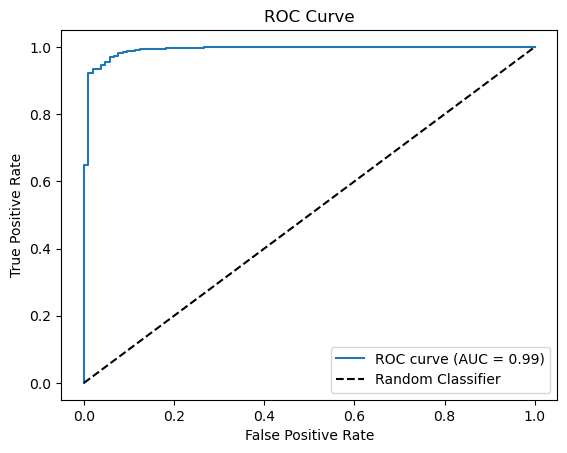

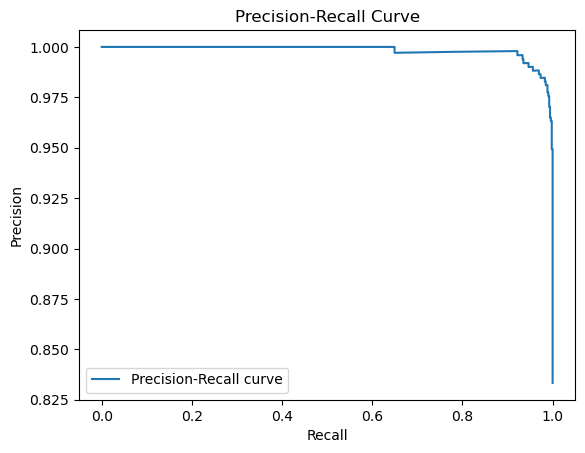

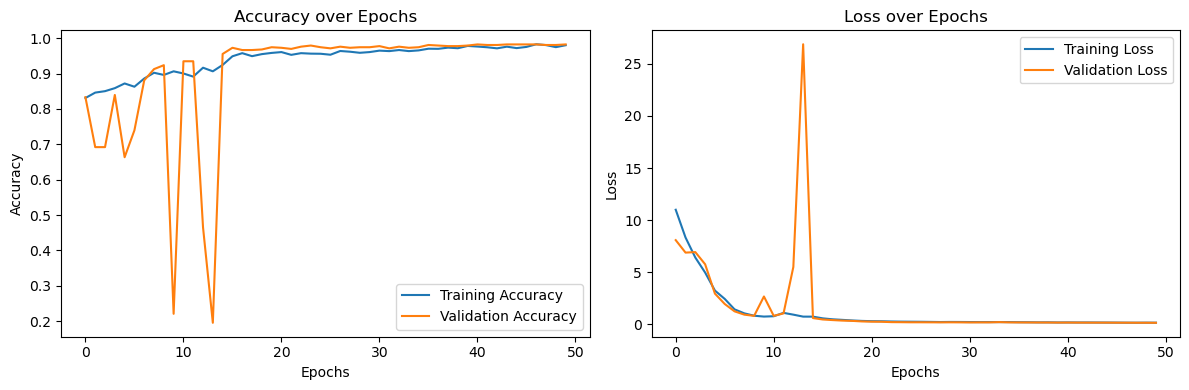

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report and Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Base directory contents: ['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']
Data shape: (4200, 128, 128, 1)
Labels shape: (4200,)
Train data shape: (2940, 128, 128, 1), Train labels shape: (2940,)
Validation data shape: (630, 128, 128, 1), Validation labels shape: (630,)
Test data shape: (630, 128, 128, 1), Test labels shape: (630,)


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,821,121 (56.54 MB)

 Trainable params: 14,820,737 (56.54 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


92/92 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.8125 - loss: 11.5480 - val_accuracy: 0.1651 - val_loss: 17.3942 - learning_rate: 0.0010
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 455s 5s/step - accuracy: 0.8489 - loss: 8.1850 - val_accuracy: 0.8333 - val_loss: 8.1850 - learning_rate: 0.0010
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8634 - loss: 5.9551 - val_accuracy: 0.7730 - val_loss: 5.7919 - learning_rate: 0.0010
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 503s 5s/step - accuracy: 0.8536 - loss: 4.4821 - val_accuracy: 0.4048 - val_loss: 5.4350 - learning_rate: 0.0010
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.8725 - loss: 2.9579 - val_accuracy: 0.8651 - val_loss: 3.3407 - learning_rate: 0.0010
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.8624 - loss: 2.3826 - val_accuracy: 0.8667 - val_loss: 2.7153 - learning_rate: 0.0010
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.8954 - loss: 1.5057 - val_accura

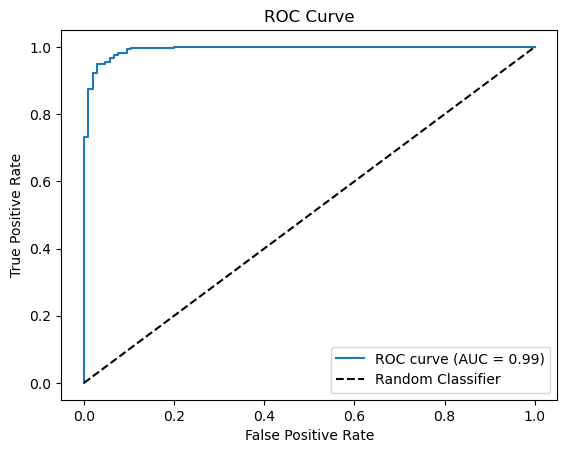

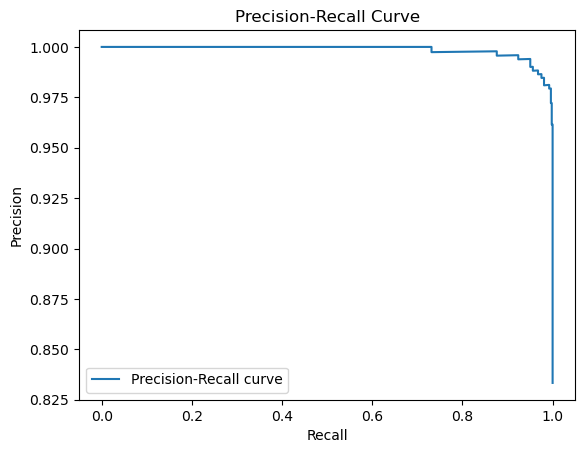

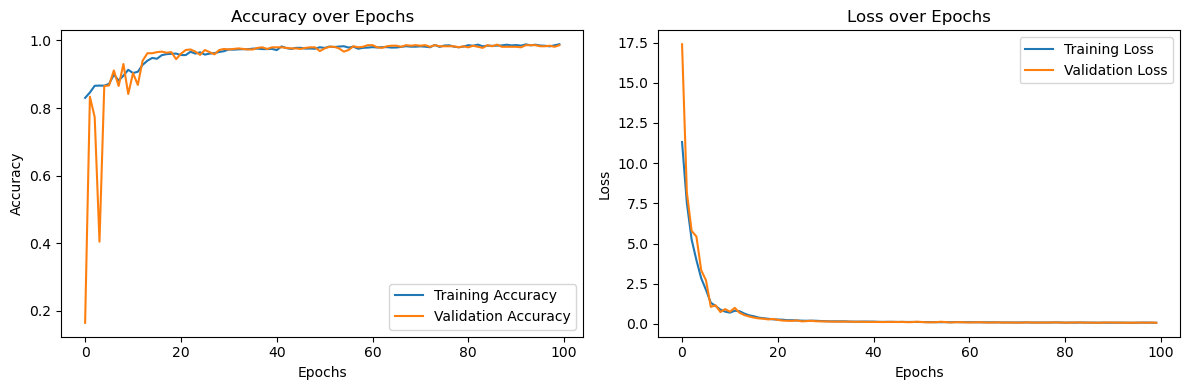

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.regularizers import l2

# Step 1: Define base path
base_path = r'C:\Users\usER\Downloads\tb_xray_data\TB_Chest_Radiography_Database'

# Check base directory contents
print("Base directory contents:", os.listdir(base_path))

# Step 2: Load and preprocess the data
img_size = 128  # Resize images to 128x128

def load_images(base_path, img_size):
    data = []
    labels = []
    categories = ['Tuberculosis', 'Normal']  # Class names
    
    for category in categories:
        path = os.path.join(base_path, category)
        class_label = categories.index(category)  # Assign 0 or 1 as label
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_img = cv2.resize(img_array, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_label)
            except Exception as e:
                print(f"Error loading image: {e}")
    
    return np.array(data), np.array(labels)

# Load data and labels
data, labels = load_images(base_path, img_size)
data = data / 255.0  # Normalize pixel values to [0, 1]

# Reshape data to fit the model input requirements (128, 128, 1)
data = data.reshape(-1, img_size, img_size, 1)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

# Step 3: Split the dataset into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Step 4: Data Augmentation
data_generator = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

data_generator.fit(X_train)

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=0.00001)

history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr]
)

# Step 7: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Step 9: Classification Report and Confusion Matrix
print("Classification Report:\n", classification_report(y_test, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_classes))

# Step 10: ROC and Precision-Recall Curves
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
 